# Resultados del proyecto — Lab 02 · Equipo 3

Todos los resultados del proyecto en un solo lugar. El notebook **solo carga** `results/` y las
figuras de `docs/figuras/` que genera `python main.py`; no recalcula ni reoptimiza nada
(CLAUDE.md, secciones 9 y 10).

Orden: corrida → datos → régimen (P3) → portafolio (P4) → corrida base (P1) → diagnóstico y
robustez (P2) → walk-forward → desempeño por régimen → backtests finales → impacto de mercado y
auditoría de sesgos.

In [1]:
import os
import pickle
from pathlib import Path

# Los pickles guardan objetos de src/ (por ejemplo, BacktestResult): se trabaja desde la raíz.
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

import pandas as pd
from IPython.display import Image, Markdown, display

RESULTS = Path("results")
FIGURES = Path("docs") / "figuras"
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.4f}".format)

r = {path.stem: pickle.load(open(path, "rb")) for path in sorted(RESULTS.glob("*.pkl"))}
sorted(r)

['corrida',
 'corrida_base',
 'datos_regimen',
 'diagnostico',
 'final_backtests',
 'impacto_mercado',
 'portafolio',
 'regimen',
 'regimen_desempeno',
 'robustez',
 'walk_forward']

## Corrida

In [2]:
corrida = r["corrida"]
display(pd.Series(corrida))
if not corrida["final_run"]:
    display(Markdown("**Corrida previa: los datos terminan en validation y test no se tocó.**"))

commit                 400592685cc880fe7e010998a606fa39be3b74dd
uncommitted_changes                                        True
final_run                                                 False
elapsed_seconds                                      1,573.4926
finished                                    2026-10-06 17:52:09
dtype: object

**Corrida previa: los datos terminan en validation y test no se tocó.**

## Datos y auditoría (P1)

In [3]:
display(r["datos_regimen"]["audit"])

,n_obs,start,end,nan,non_positive,high_lt_low,open_outside,close_outside,zero_volume,dropped_dates
AAPL,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
MSFT,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
META,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
AMD,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
XOM,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
SMH,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
GLD,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0
COPX,2449,2017-01-03,2026-09-30,0,0,0,0,0,0,0


## Régimen de mercado (P3)

### Comparación de métodos (ajuste en train, validation con el modelo congelado)

In [4]:
display(r["regimen"]["comparison"])

silhouette  duracion_media  transiciones_por_mes  pct_tendencia  pct_reversion  pct_crisis
metodo bloque                                                                                                
rules  train           0.2347         11.2000                1.8542        41.6667        38.2937     20.0397
       validation      0.3378         25.0500                0.7917        27.7445        20.3593     51.8962
kmeans train           0.3845         17.0847                1.2083        31.5476        61.9048      6.5476
       validation      0.3003         16.1613                1.2500        19.3613        80.6387      0.0000
hmm    train           0.2039         67.2000                0.2917        61.1111        26.3889     12.5000
       validation      0.1987        167.0000                0.0833        27.9441        72.0559      0.0000

### Etiqueta operable: validación por bloque y % de tiempo en cada régimen

In [5]:
display(r["regimen"]["validation_by_block"])
display(r["regimen"]["validation"]["pct_tiempo"].round(1))
display(r["regimen"]["validation"]["duracion_por_regimen"].rename("duración media (días)"))

,silhouette,duracion_media,transiciones_por_mes
train,0.1317,12.4444,1.6667
validation,0.3432,19.2692,1.0417


regime,tendencia,reversion,crisis
train,40.0000,27.6000,32.4000
validation,30.3000,18.6000,51.1000


first
crisis      64.7778
reversion    7.5714
tendencia   11.5625
Name: duración media (días), dtype: float64

### Etiqueta filtrada contra Viterbi

Coincidencia HMM filtrada vs Viterbi: 98.8%


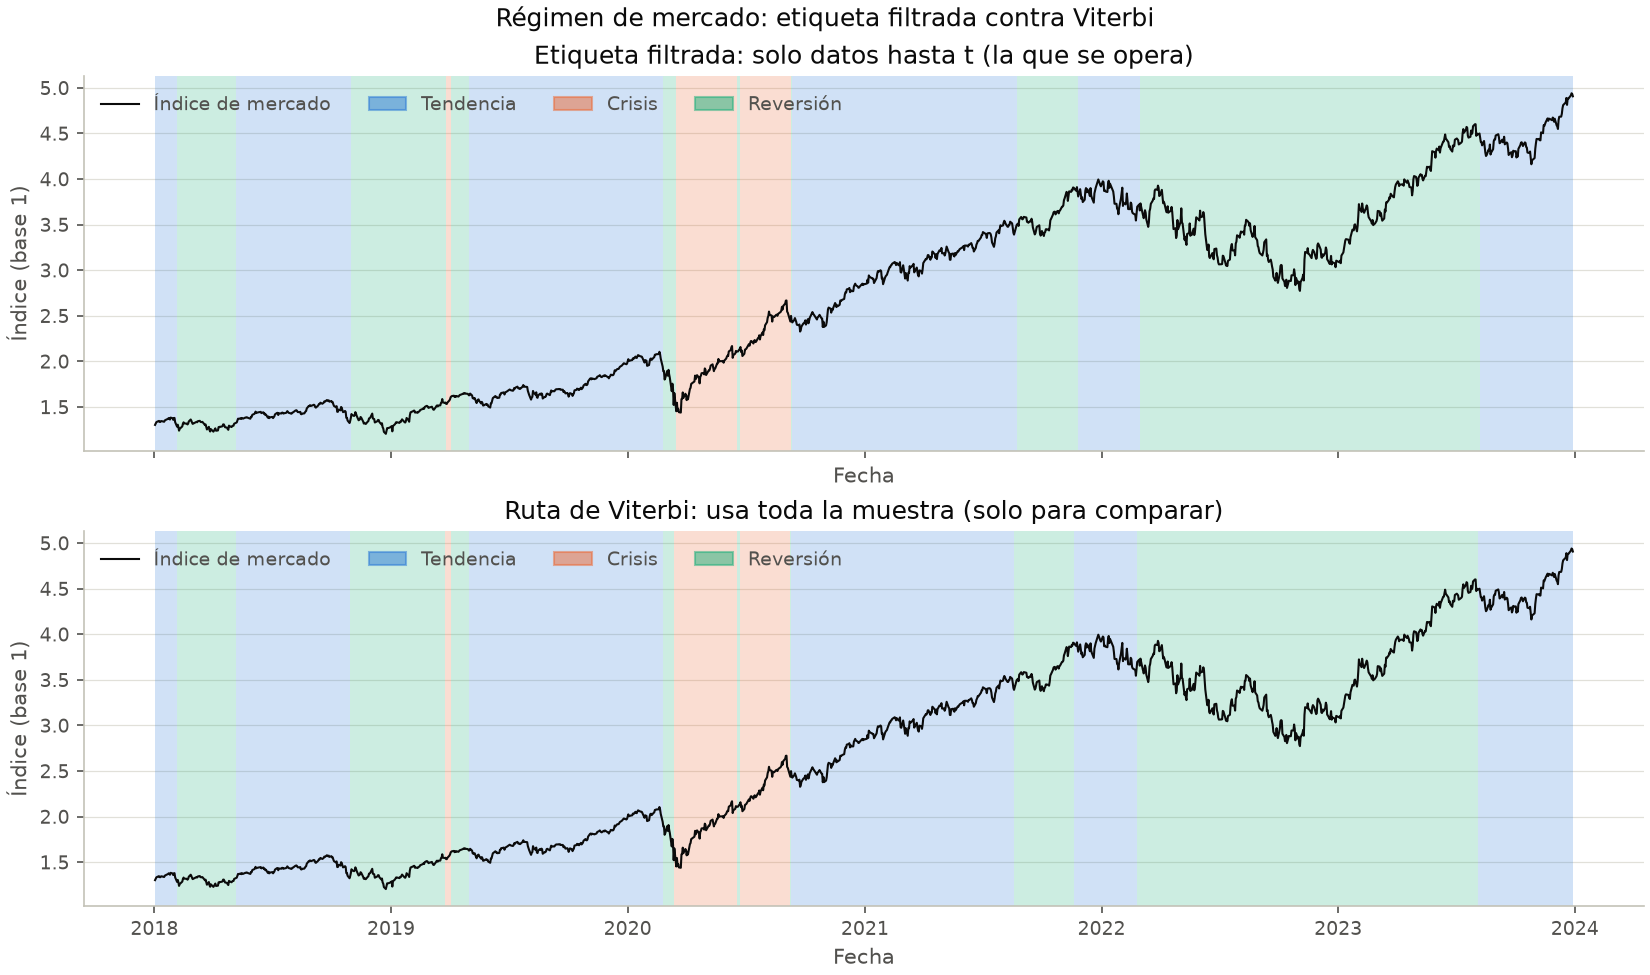

In [6]:
print(f"Coincidencia HMM filtrada vs Viterbi: {r['regimen']['hmm_agreement']:.1%}")
display(Image(filename=FIGURES / "regimen_filtrada_vs_viterbi.png"))

### Variables y correlación por régimen (train)

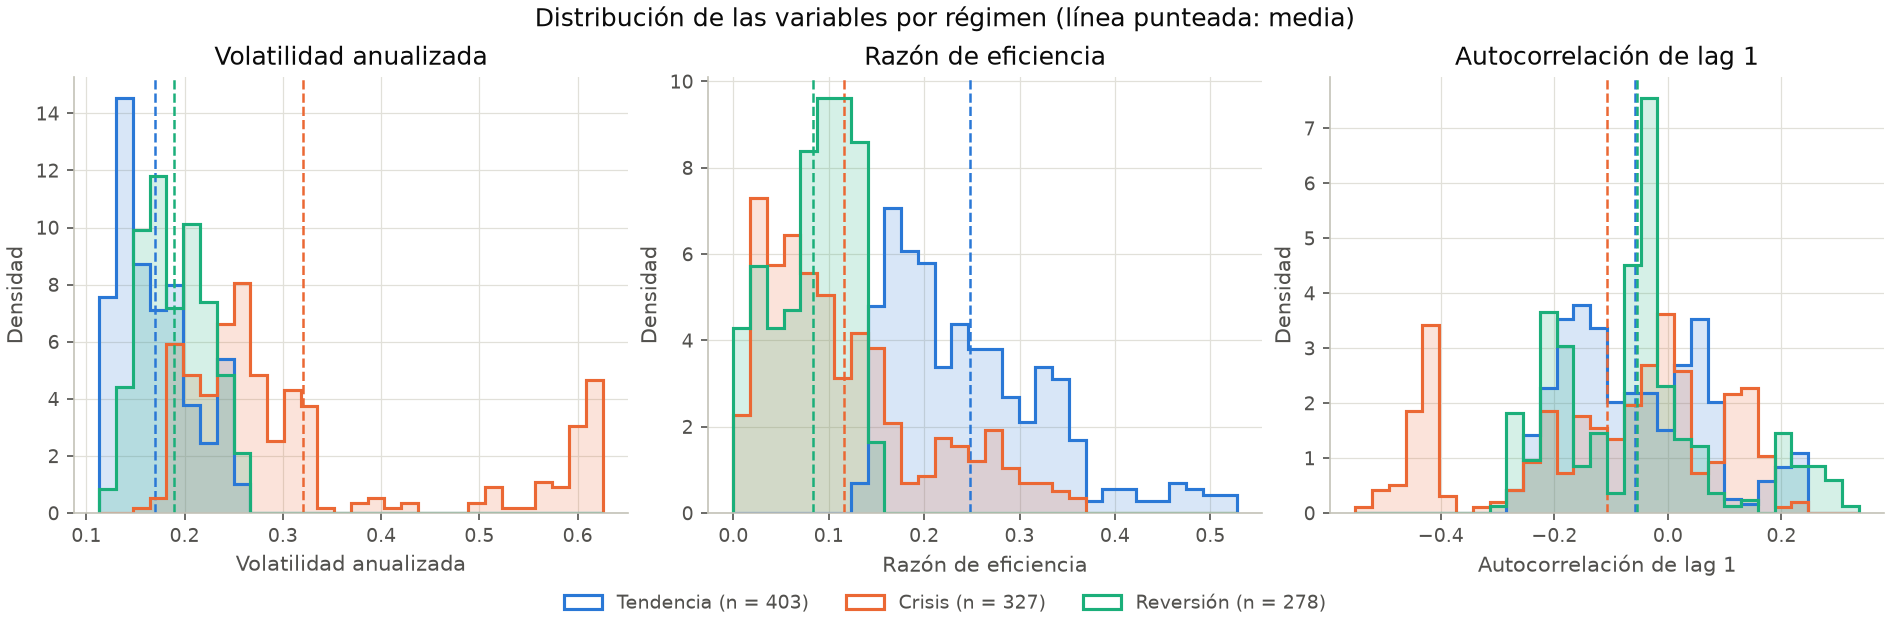

In [7]:
display(Image(filename=FIGURES / "regimen_variables_train.png"))

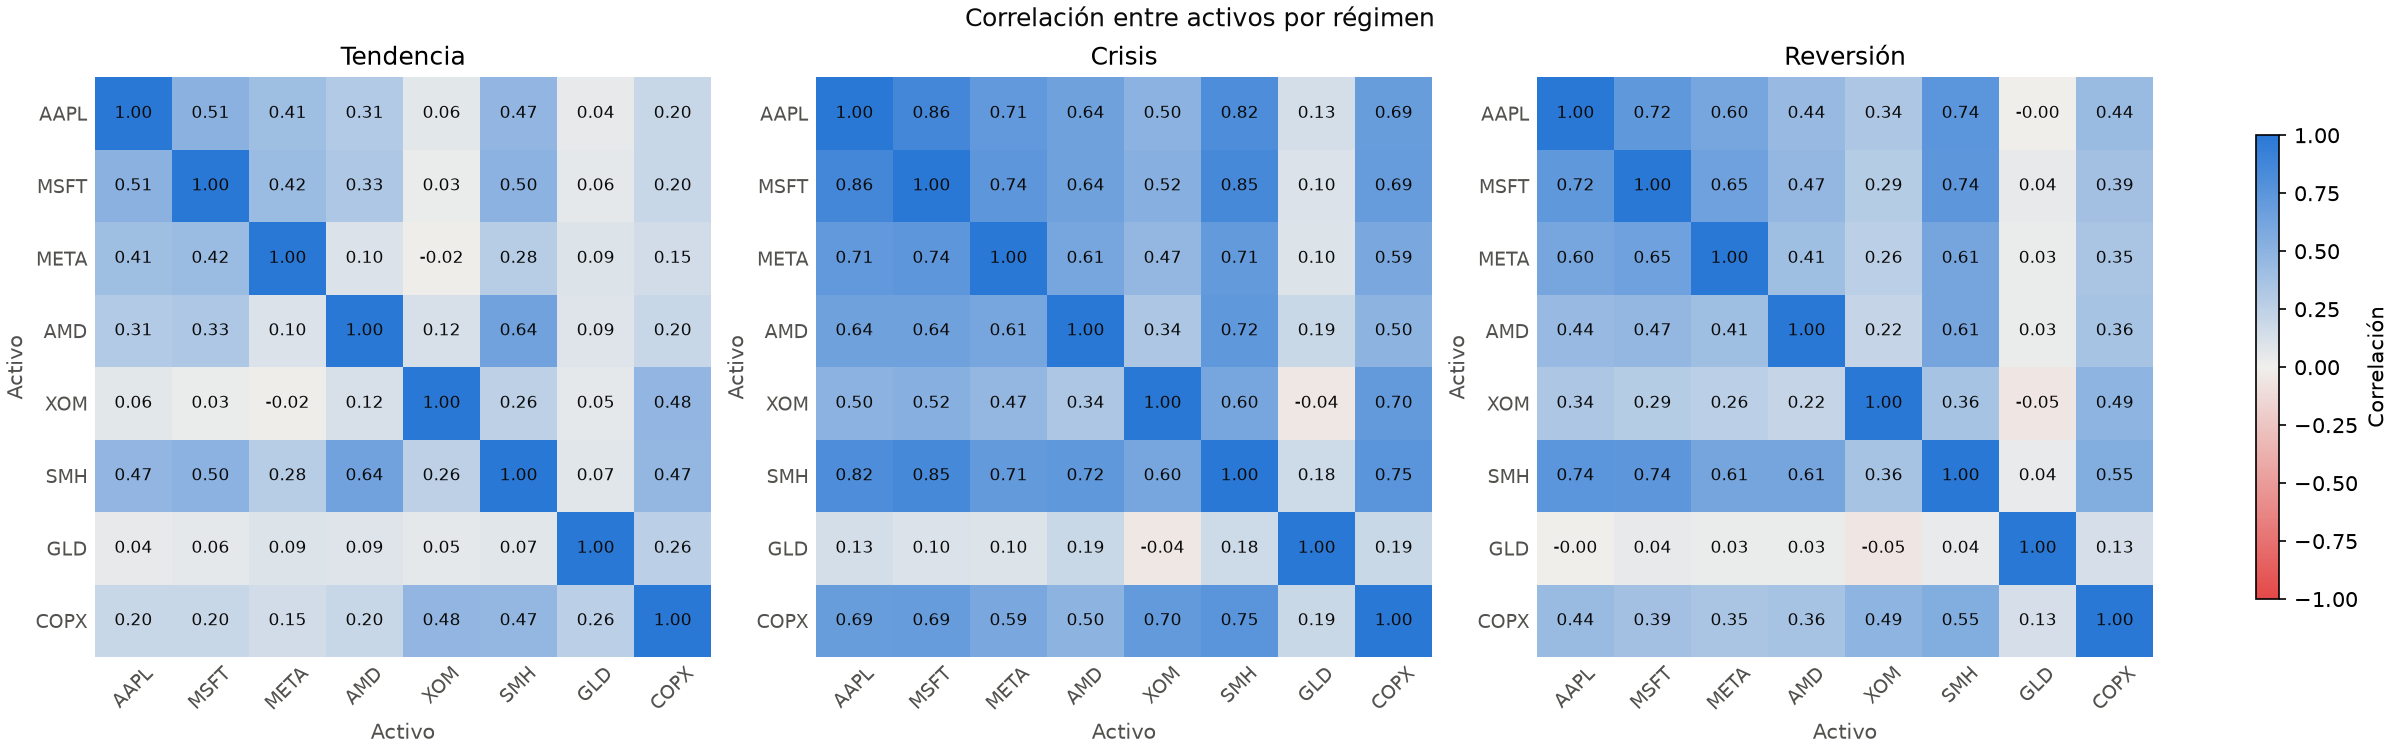

In [8]:
display(Image(filename=FIGURES / "regimen_correlacion_train.png"))

## Portafolio con θ base, train (P4)

### Estabilidad de los pesos por estimador

In [9]:
display(r["portafolio"]["weight_stability"])

,AAPL,MSFT,META,AMD,XOM,SMH,GLD,COPX,mean_std,n_reviews
sample,0.0192,0.0223,0.0151,0.0172,0.0297,0.0123,0.0908,0.0131,0.0275,48
ewma,0.0204,0.0225,0.0154,0.0176,0.0277,0.0125,0.0905,0.0125,0.0274,48
ledoit_wolf,0.0178,0.0191,0.0113,0.0163,0.0266,0.0111,0.0706,0.0114,0.0230,48


### Contribuciones al riesgo: Risk Parity contra pesos iguales

,AAPL,MSFT,META,AMD,XOM,SMH,GLD,COPX,spread,ann_vol
risk_parity,0.1250,0.1250,0.1250,0.1250,0.1250,0.1250,0.1250,0.1250,0.0000,0.1659
equal,0.1303,0.1170,0.1336,0.2365,0.0871,0.1483,0.0162,0.1309,0.2206,0.2218


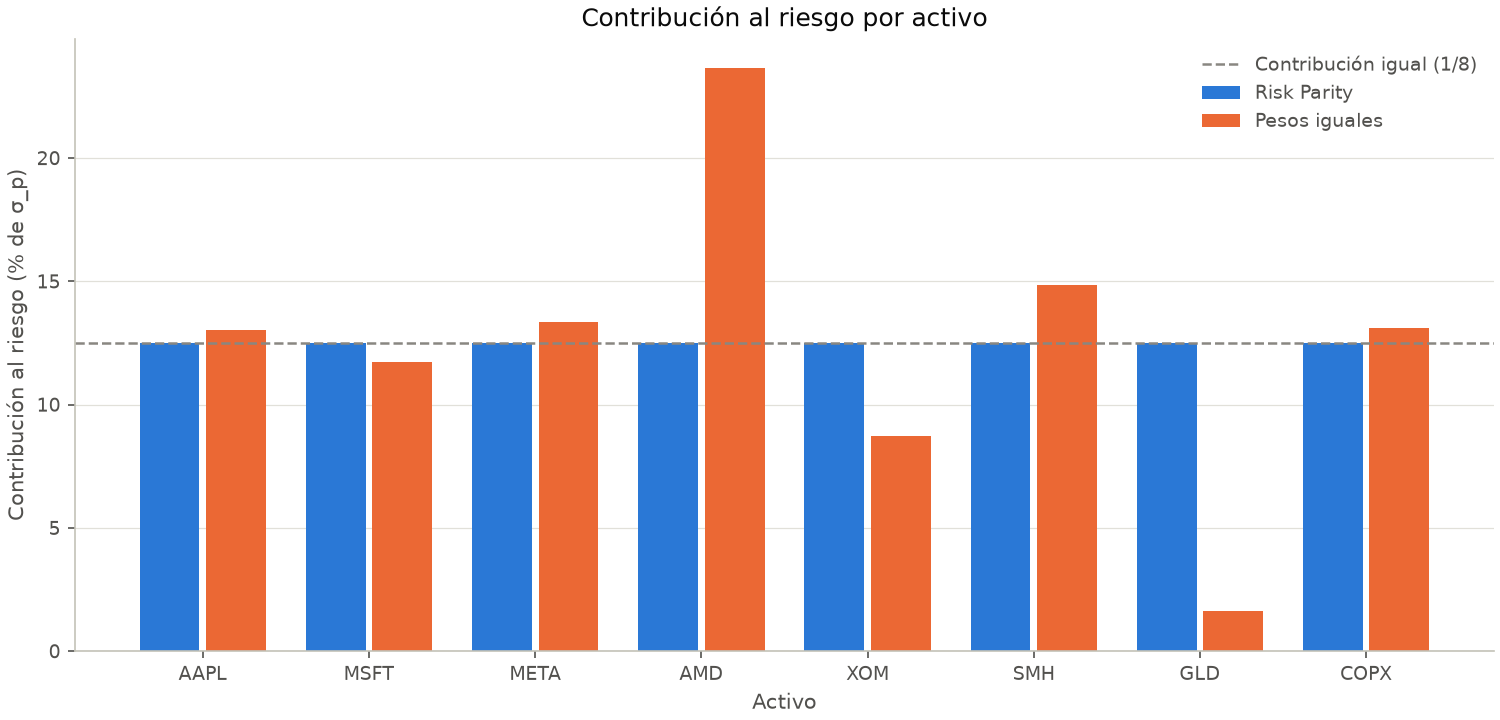

In [10]:
display(r["portafolio"]["risk_contributions"])
display(Image(filename=FIGURES / "portafolio_contribuciones_riesgo.png"))

### Risk Parity, pesos iguales y activos individuales

In [11]:
columnas = ["ann_return", "ann_vol", "sharpe", "calmar", "max_drawdown", "n_trades", "win_rate"]
display(r["portafolio"]["performance"]["train"][columnas])

,ann_return,ann_vol,sharpe,calmar,max_drawdown,n_trades,win_rate
risk_parity,0.0059,0.0493,-0.0750,0.0725,-0.0816,375,0.4427
equal,0.0161,0.0653,0.1109,0.1623,-0.0990,375,0.4427
AAPL,0.2174,0.2422,0.8885,0.9217,-0.2359,45,0.5778
MSFT,-0.0781,0.1975,-0.3663,-0.1885,-0.4141,47,0.3830
META,-0.0630,0.2849,-0.1219,-0.1869,-0.3370,47,0.4255
AMD,0.0321,0.4068,0.2516,0.0558,-0.5750,56,0.4286
XOM,0.0831,0.2423,0.4054,0.2057,-0.4041,45,0.4222
SMH,-0.0736,0.2329,-0.2588,-0.2228,-0.3303,43,0.4186
GLD,-0.0440,0.0865,-0.6013,-0.2359,-0.1864,48,0.3958
COPX,0.1581,0.2570,0.6554,0.5231,-0.3023,49,0.4490


### Barrido de rebalanceo

,frequency,band,n_rebalances,turnover,gross_return,total_cost,net_return,n_trades
0,W,0.0000,209,0.5999,0.1204,"88,874.6187",0.0315,375
1,W,0.0250,90,0.4852,0.1180,"88,770.8885",0.0292,375
2,W,0.0500,46,0.3815,0.1133,"88,422.3851",0.0249,375
3,W,0.1000,22,0.3267,0.1126,"88,289.9511",0.0243,375
4,W,0.2000,7,0.1909,0.0922,"86,915.2697",0.0053,375
5,M,0.0000,48,0.3817,0.1161,"88,865.2127",0.0272,375
6,M,0.0250,40,0.3678,0.1150,"88,757.4760",0.0262,375
7,M,0.0500,29,0.3362,0.1125,"88,640.0309",0.0239,375
8,M,0.1000,18,0.3018,0.1076,"88,452.6071",0.0192,375
9,M,0.2000,7,0.1960,0.0923,"87,372.8822",0.0049,375


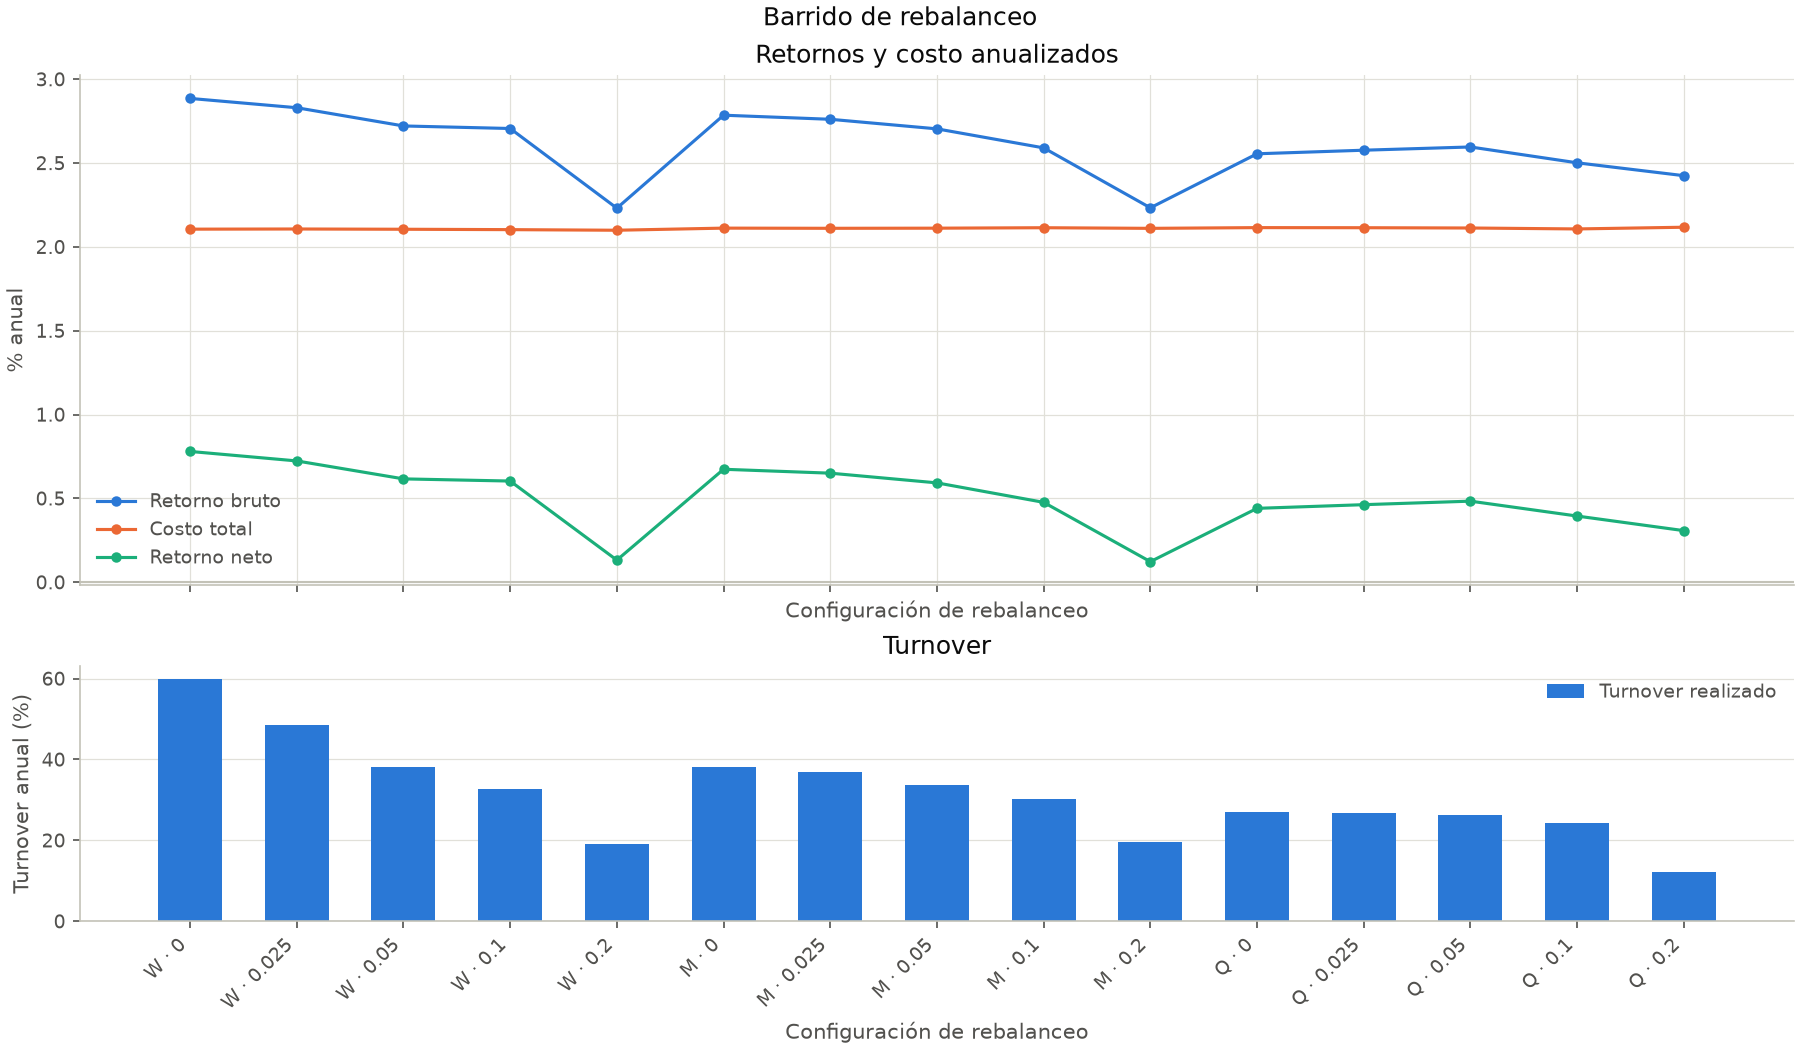

In [12]:
display(r["portafolio"]["sweep"]["train"])
display(Image(filename=FIGURES / "portafolio_barrido_rebalanceo.png"))

## Corrida base sobre train (P1, tarea 4)

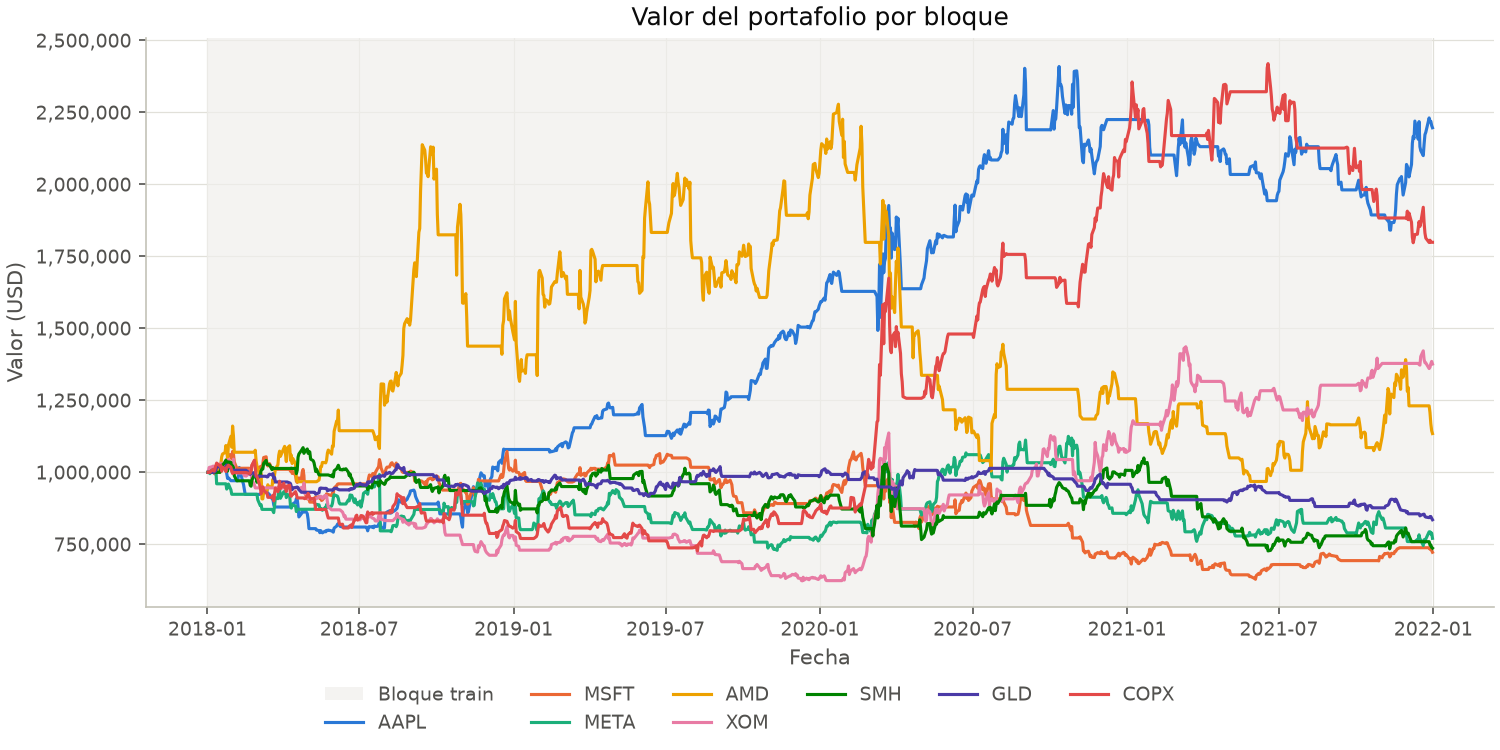

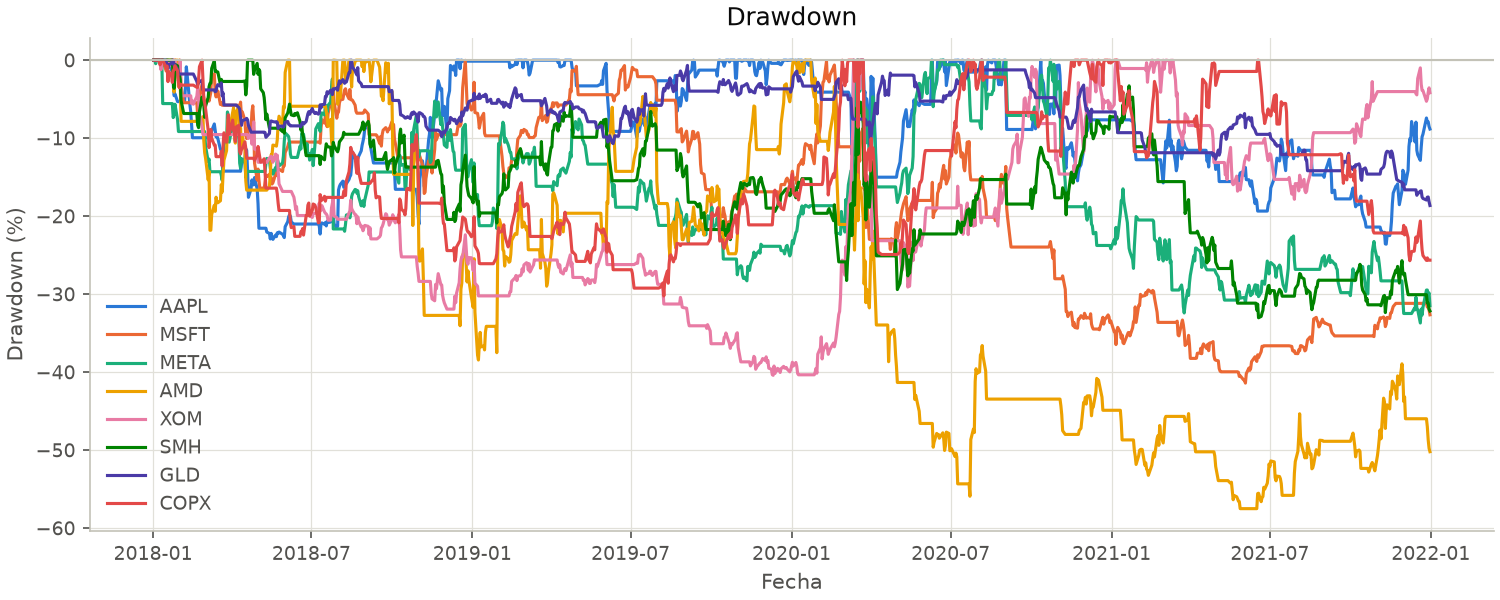

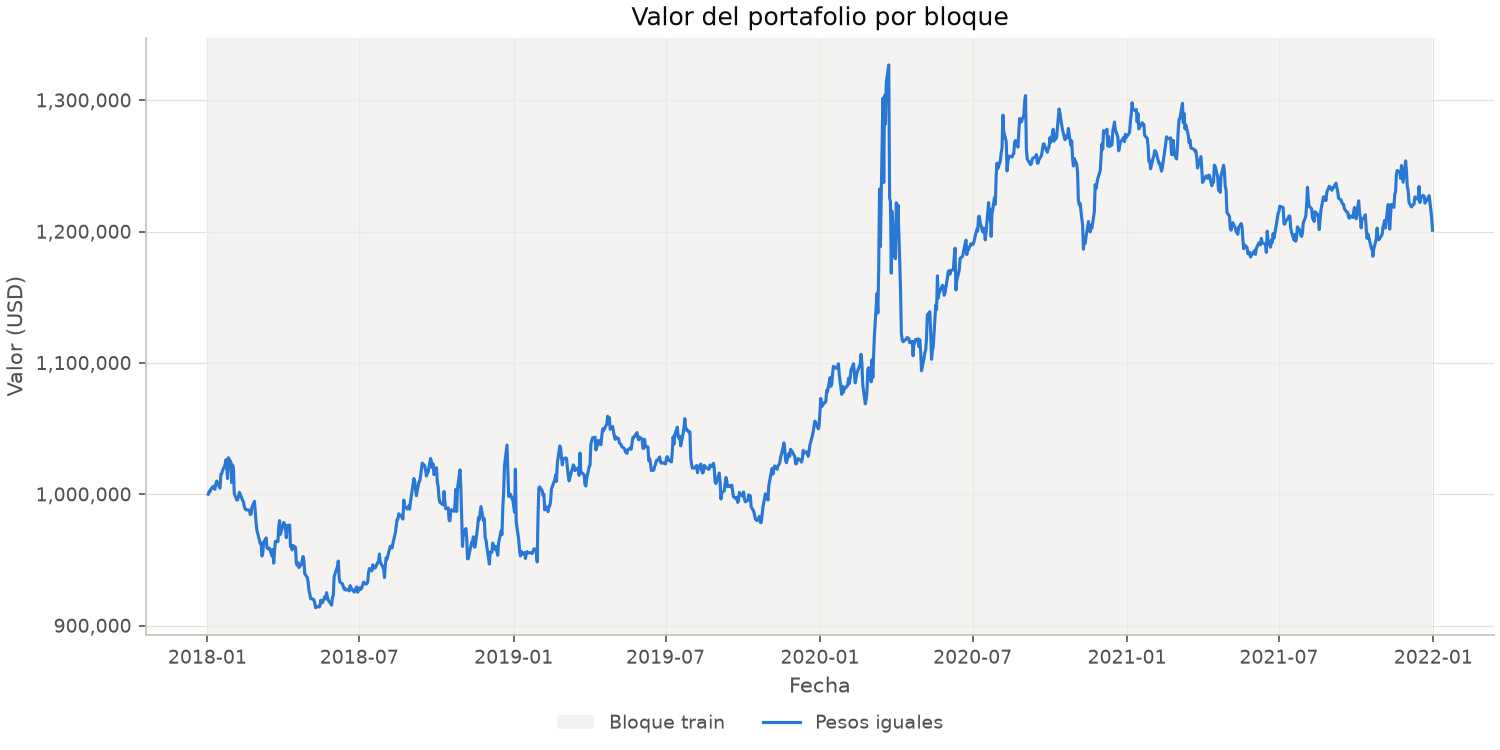

In [13]:
for name in ("base_equity_activos", "base_drawdown_activos", "base_equity_pesos_iguales"):
    display(Image(filename=FIGURES / f"{name}.png"))

## Estudios de diagnóstico (P2)

In [14]:
resumen = pd.DataFrame({k: v["user_attrs"] for k, v in r["diagnostico"]["studies"].items()}).T
display(resumen[["n_trials_evaluated", "n_trials_feasible", "minimum_trades", "elapsed_seconds"]])
display(pd.Series(r["diagnostico"]["plateau"], name="θ* (medoide de la meseta TPE)"))

,n_trials_evaluated,n_trials_feasible,minimum_trades,elapsed_seconds
random,200,199,192,11.7079
tpe,200,200,192,11.9595


sma_fast       19.0000
sma_slow       64.0000
rsi_window     20.0000
rsi_lo         39.0000
rsi_hi         65.0000
k_stop          3.8145
reward_ratio    3.6443
max_holding    40.0000
Name: θ* (medoide de la meseta TPE), dtype: float64

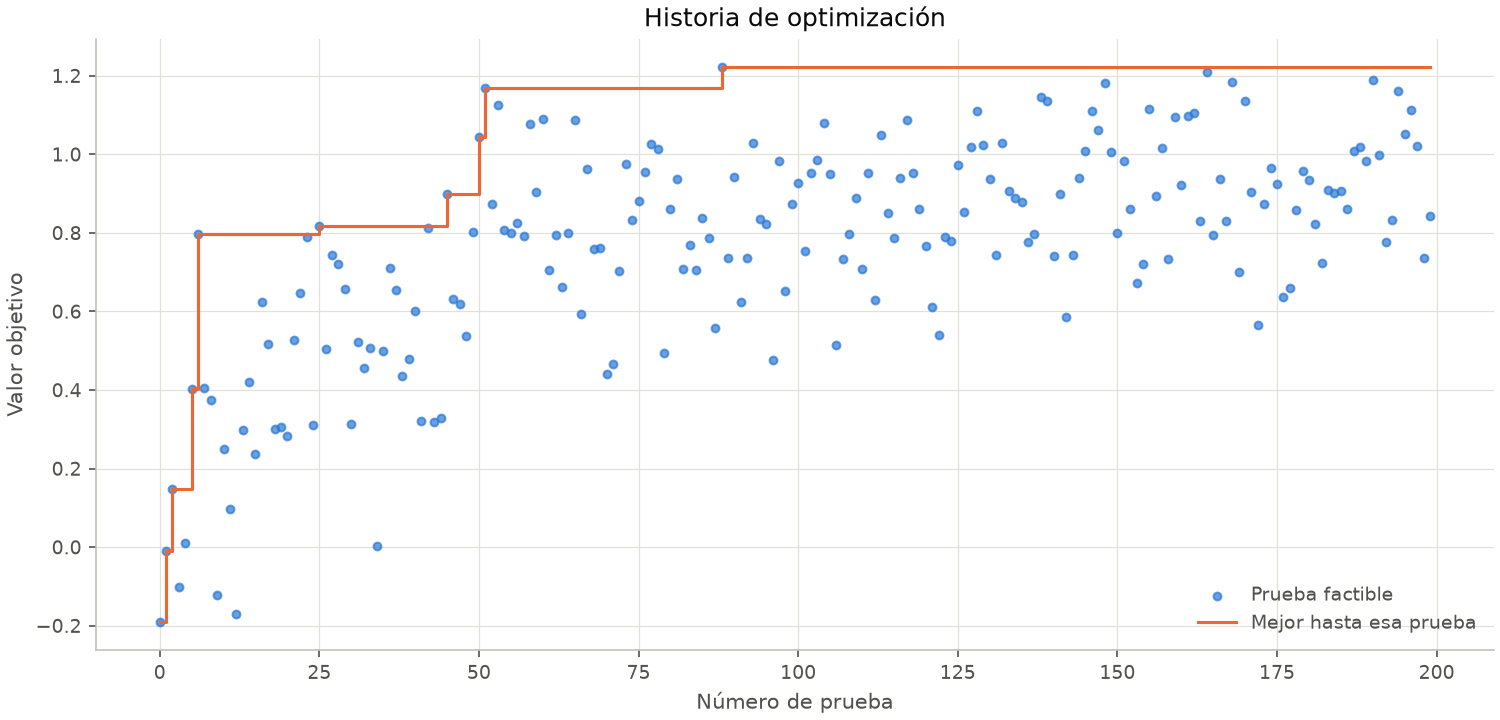

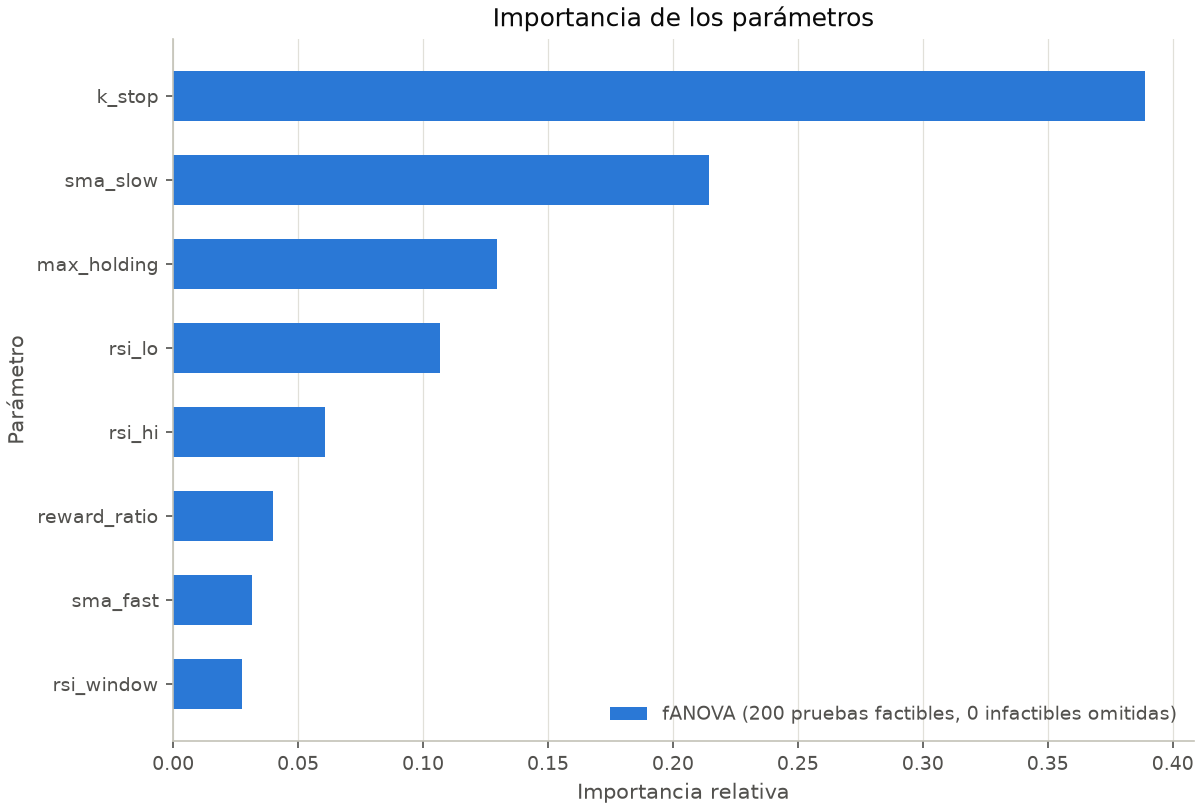

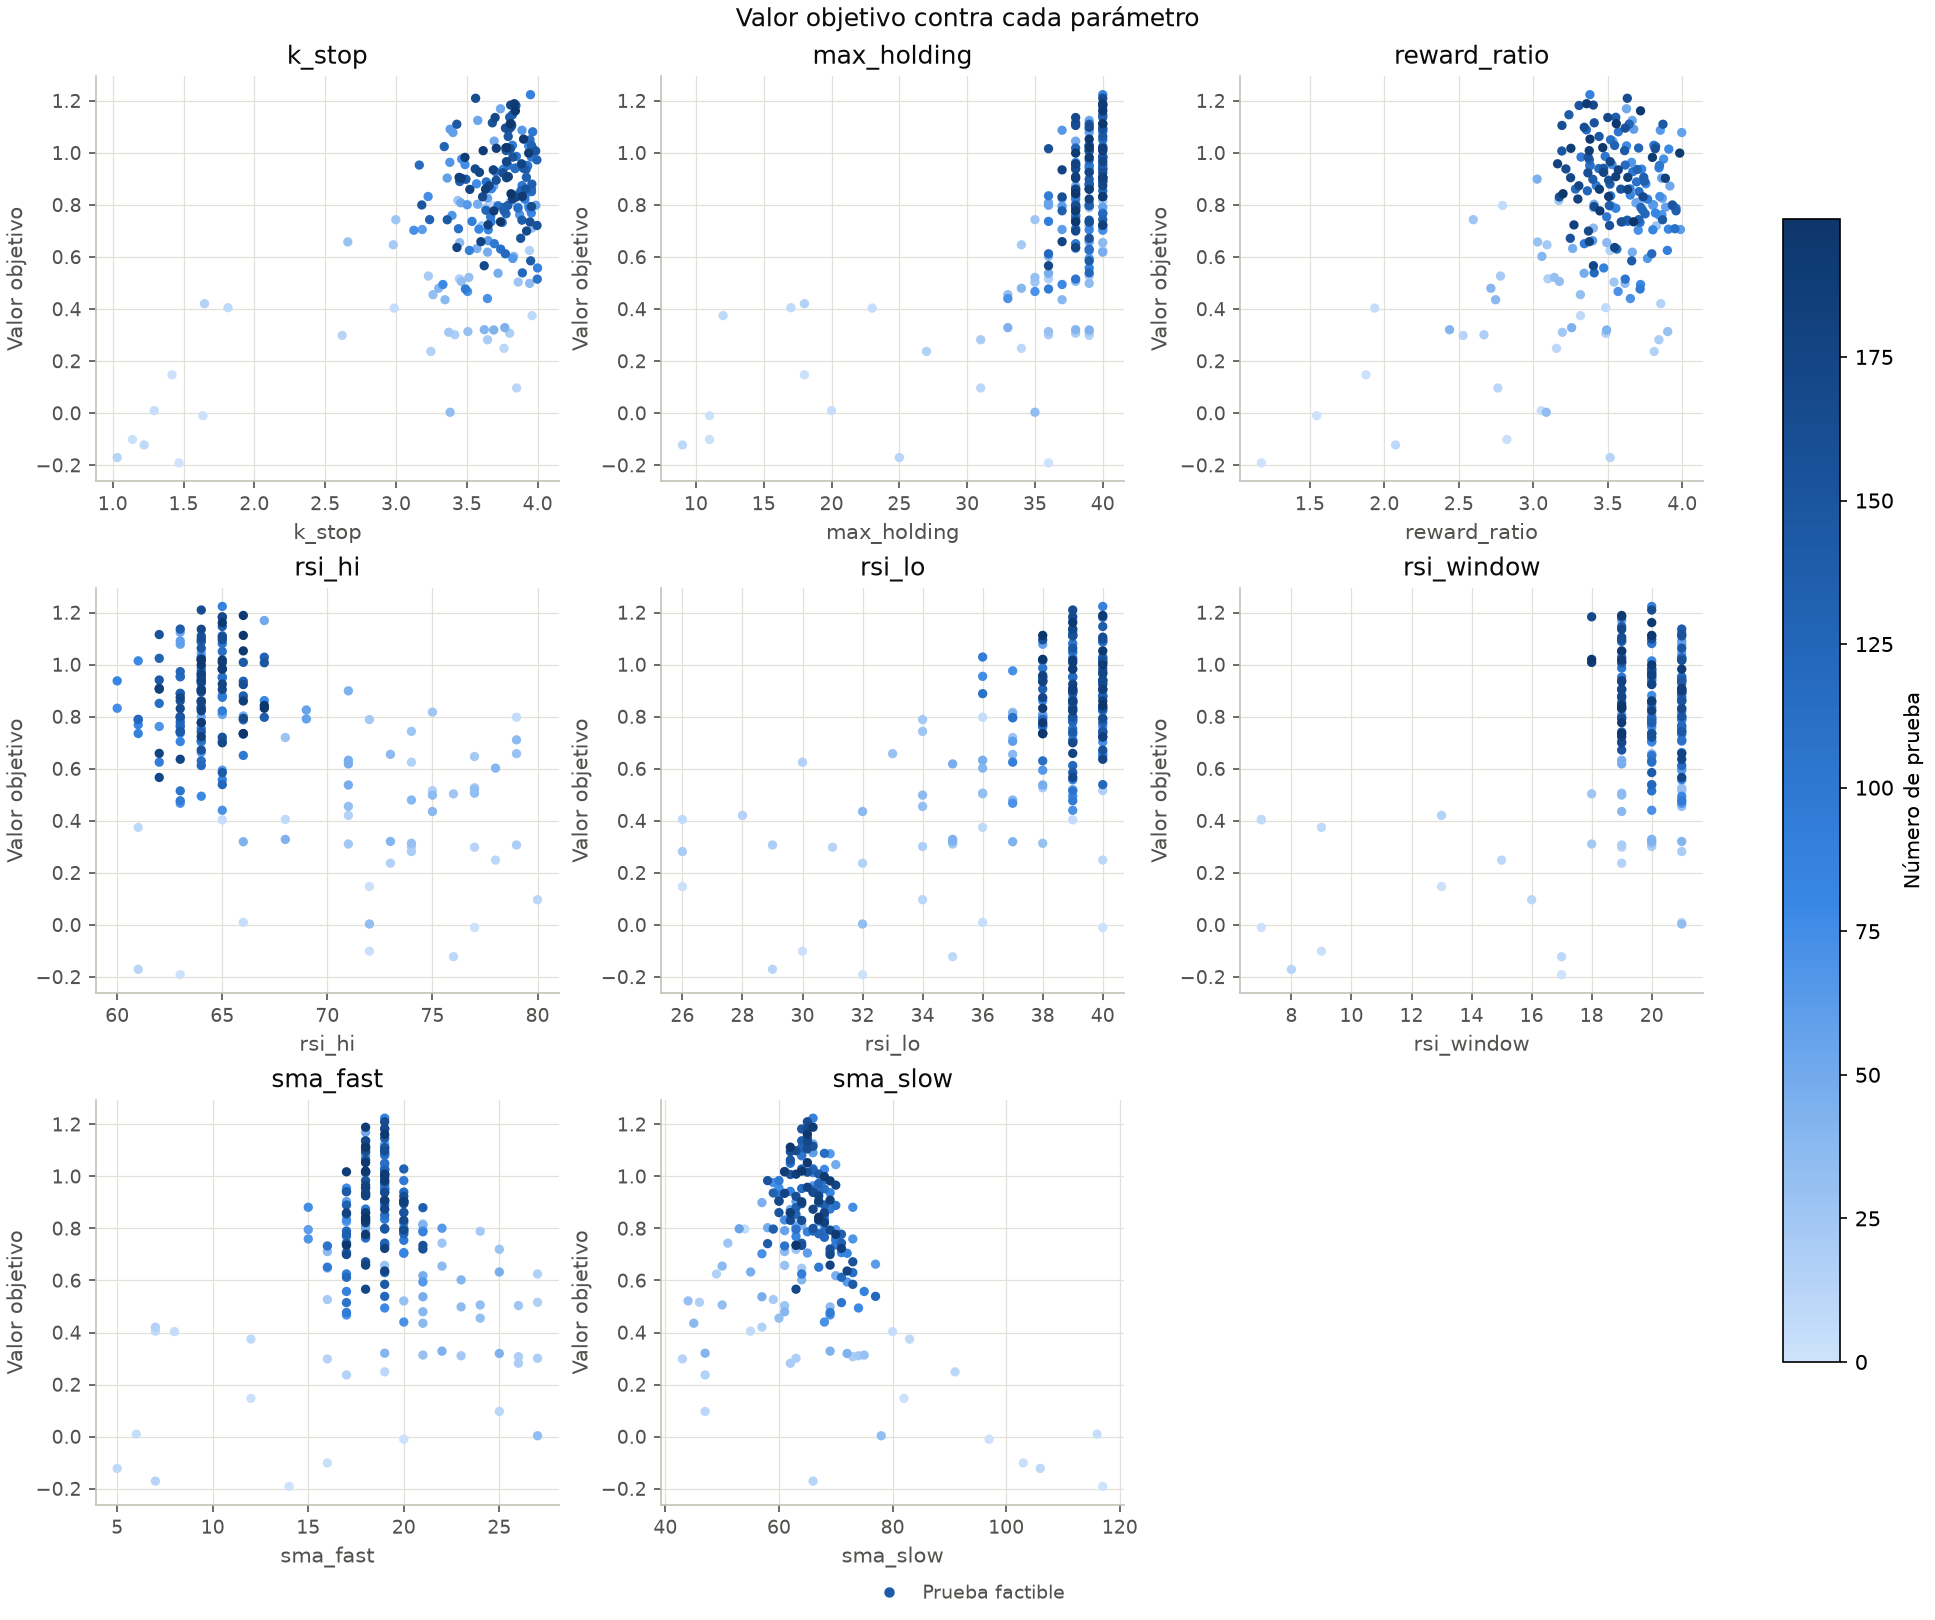

In [15]:
for name in ("diagnostico_historia_tpe", "diagnostico_importancia_tpe", "diagnostico_slices_tpe"):
    display(Image(filename=FIGURES / f"{name}.png"))

### Superficie 3D del random search (corte de 2 de las 9 dimensiones)

Dimensiones: k_stop y sma_slow


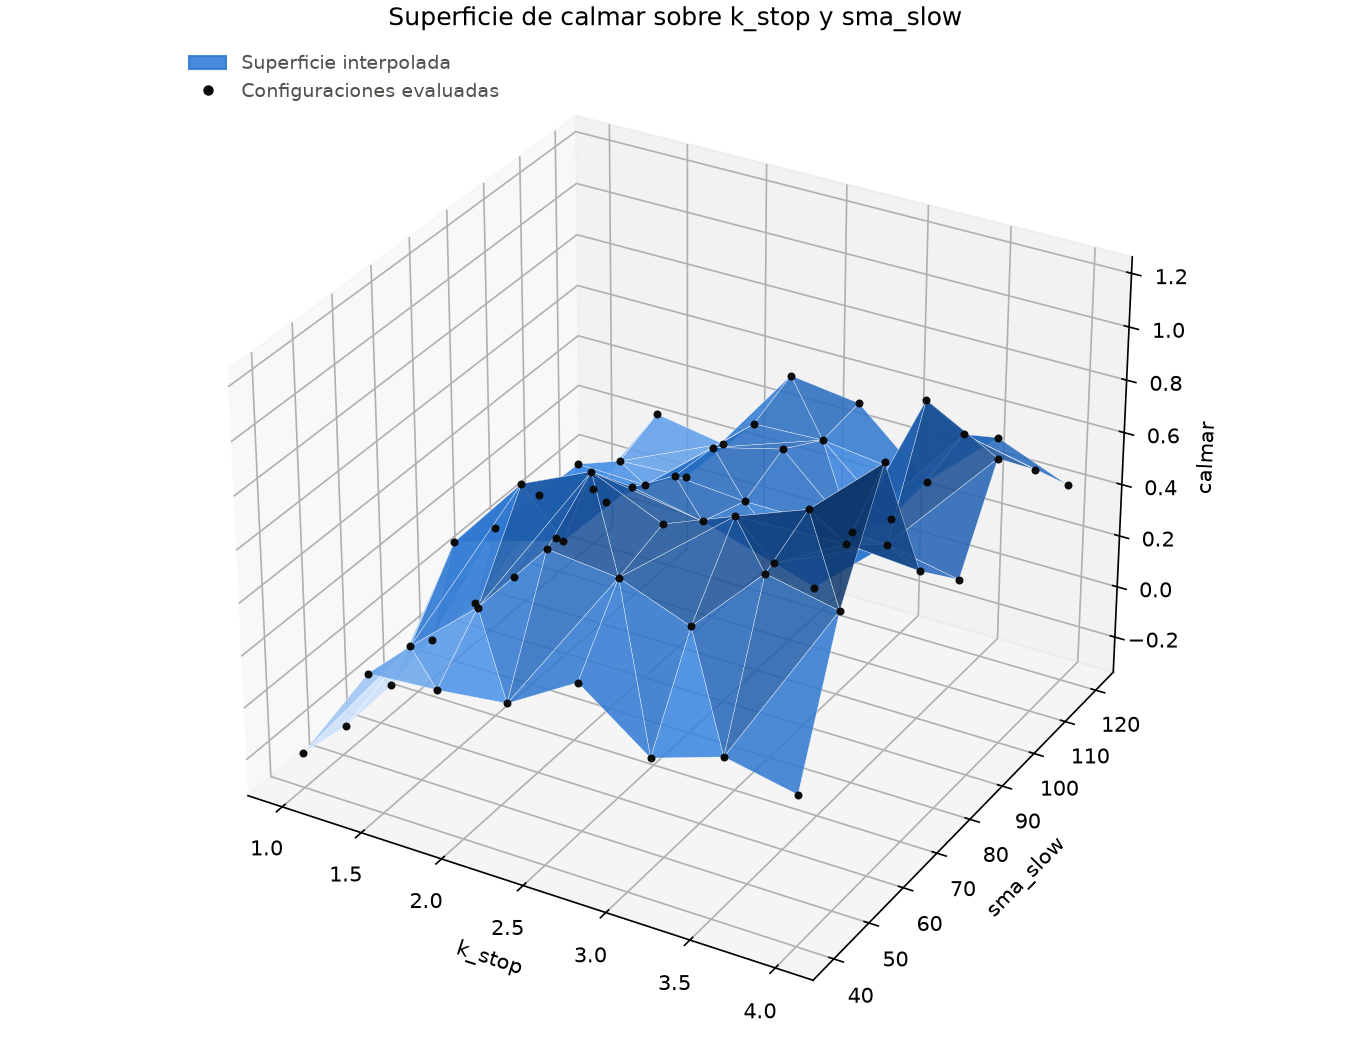

In [16]:
superficie = r["diagnostico"]["surface"]
print("Dimensiones:", superficie["x"], "y", superficie["y"])
display(Image(filename=FIGURES / "diagnostico_superficie_random.png"))

## Robustez con θ*, train (P2)

### Sensibilidad ±20%

factor,0.8000,1.2000
parameter,,
k_stop,-0.0986,0.0366
max_holding,-0.4442,0.0459
reward_ratio,-0.0828,0.0401
rsi_hi,-0.4387,-0.0162
rsi_lo,-0.2117,0.1888
rsi_window,0.0688,-0.1010
sma_fast,-0.2803,-0.3752
sma_slow,-0.3415,-0.6500


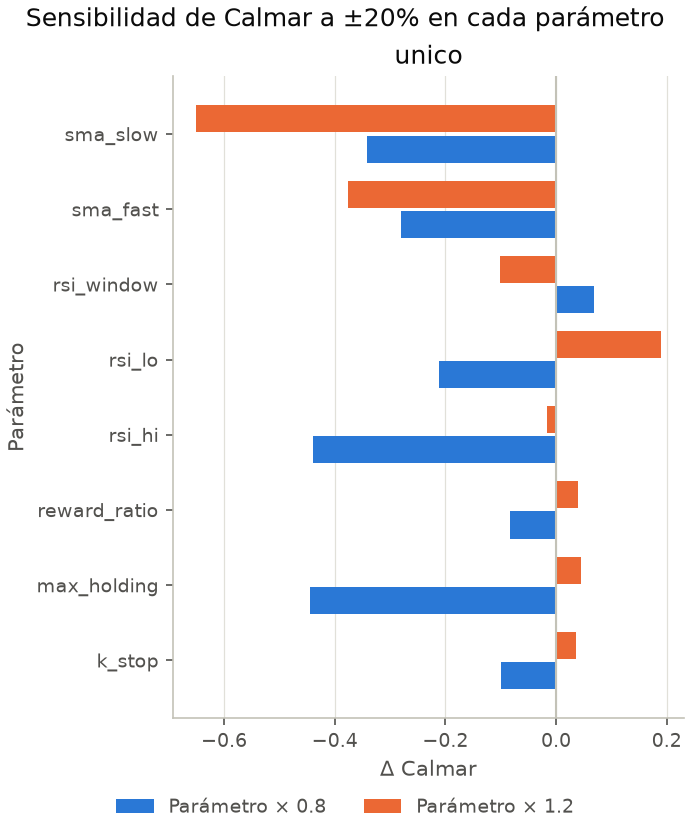

In [17]:
display(r["robustez"]["sensitivity"].pivot_table(index="parameter", columns="factor", values="delta_calmar"))
display(Image(filename=FIGURES / "robustez_sensibilidad.png"))

### Curva de costos

,net_return,calmar,n_trades
round_trip_bps,,,
0.0000,0.1314,1.2742,202
5.0000,0.1282,1.2407,202
10.0000,0.1249,1.2073,202
15.0000,0.1217,1.1742,202
20.0000,0.1186,1.1413,202
25.0000,0.1154,1.1087,202
30.0000,0.1122,1.0762,202
35.0000,0.1091,1.0439,202
40.0000,0.1059,1.0119,202


break_even_bps       NaN
base_cost_bps    29.0000
margin_bps           NaN
Name: 0.0, dtype: float64

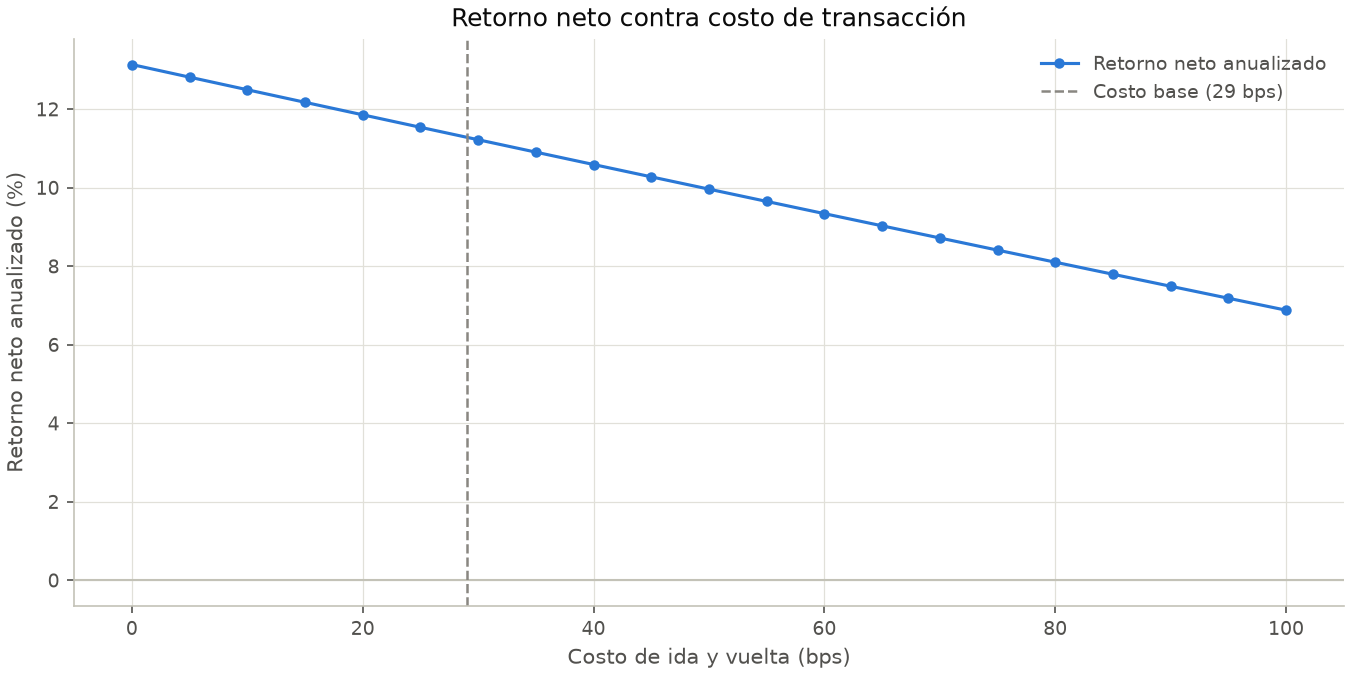

In [18]:
curva = r["robustez"]["cost_curve"]
display(curva[["net_return", "calmar", "n_trades"]])
display(curva[["break_even_bps", "base_cost_bps", "margin_bps"]].iloc[0])
display(Image(filename=FIGURES / "robustez_costos.png"))

### Pregunta 1: cada indicador solo contra la regla 2 de 3

In [19]:
display(r["robustez"]["single_indicator"])

,n_trades,calmar
strategy,,
2_de_3,202,1.0827
sma,140,0.3007
macd,561,-0.0655
rsi,673,0.0421


### Correlación de votos SMA–MACD (SPEC punto 9)

In [20]:
display(r["robustez"]["sma_macd_correlation"])

,correlation,n_obs
ticker,,
AAPL,-0.1072,1008
MSFT,-0.1665,1008
META,-0.0998,1008
AMD,-0.1416,1008
XOM,-0.1488,1008
SMH,-0.1905,1008
GLD,-0.1412,1008
COPX,-0.1553,1008
pooled,-0.1351,8064


## Walk-forward (P2)

In [21]:
wf = r["walk_forward"]
print(f"Configuraciones evaluadas: {wf['n_trials_total']:,} · tiempo de optimización: "
      f"{wf['elapsed_seconds'] / 60:,.1f} min")
eficiencia = pd.DataFrame({"ann_return": wf["efficiency"], "calmar": wf["efficiency_calmar"]})
eficiencia.index.names = ["modo", "por_regimen"]
display(eficiencia)

Configuraciones evaluadas: 88,200 · tiempo de optimización: 25.5 min


ann_return  calmar
modo     por_regimen                    
rolling  True             0.1374  0.0211
         False           -0.0702 -0.0075
anchored True             0.0885  0.0217
         False            0.1510  0.0486

### Ventanas del walk-forward rolling por régimen: IS contra OOS

In [22]:
ventanas = wf["folds"][("rolling", True)]
display(ventanas[["is_calmar", "oos_calmar", "is_ann_return", "oos_ann_return"]].describe())
print("Ventanas con algún régimen en efectivo:", (ventanas["cash_regimes"] != "").sum())
display(ventanas.tail(12))

,is_calmar,oos_calmar,is_ann_return,oos_ann_return
count,66.0000,66.0000,66.0000,66.0000
mean,5.8730,11.2991,0.0908,0.0298
std,4.2445,27.7478,0.0517,0.1866
min,-1.1055,-10.9999,-0.0403,-0.3433
25%,2.6706,-5.8369,0.0569,-0.0790
50%,5.4506,1.1511,0.0978,0.0070
75%,7.9760,16.0616,0.1299,0.1067
max,18.1585,122.4605,0.2050,0.7259


Ventanas con algún régimen en efectivo: 0


,test_start,is_calmar,oos_calmar,is_ann_return,oos_ann_return,oos_trades,cash_regimes,n_trials,seconds
fold,,,,,,,,,
54,2023-01-01,0.1978,7.8497,0.0025,0.0248,7,,300,66.1870
55,2023-02-01,1.4050,-8.7920,0.0128,-0.0827,6,,300,66.1491
56,2023-03-01,3.6400,-2.8058,0.0438,-0.0547,4,,300,60.9936
57,2023-04-01,-0.1168,6.5569,-0.0033,0.1083,3,,450,81.7618
58,2023-05-01,-0.3289,76.6620,-0.0077,0.7259,2,,450,81.0103
59,2023-06-01,4.1025,0.0755,0.1056,0.0010,2,,450,80.1732
60,2023-07-01,4.4777,-7.6030,0.1086,-0.2736,5,,450,79.0201
61,2023-08-01,2.6510,-9.3862,0.0841,-0.2562,6,,300,59.0141
62,2023-09-01,1.7415,26.5302,0.0638,0.1489,2,,300,59.1990


## θ por régimen contra θ único y desempeño por régimen (P3, pregunta 5)

ann_return  ann_vol  sharpe  calmar  max_drawdown  n_trades  win_rate
modo     variante    bloque                                                                           
rolling  por régimen train           0.0277   0.0510  0.3667  0.4571       -0.0607  217.0000    0.4332
                     validation     -0.0138   0.0531 -0.8981 -0.2060       -0.0671  128.0000    0.3750
         θ único     train           0.0120   0.0530  0.0630  0.1917       -0.0624  206.0000    0.3981
                     validation     -0.0383   0.0488 -1.4965 -0.4113       -0.0930  119.0000    0.3445
anchored por régimen train           0.0122   0.0524  0.0672  0.1568       -0.0776  211.0000    0.4787
                     validation     -0.0063   0.0575 -0.6941 -0.0961       -0.0659   60.0000    0.1500
         θ único     train           0.0222   0.0530  0.2530  0.4042       -0.0549  224.0000    0.4554
                     validation     -0.0116   0.0567 -0.7976 -0.1546       -0.0752   71.0000    0.0423

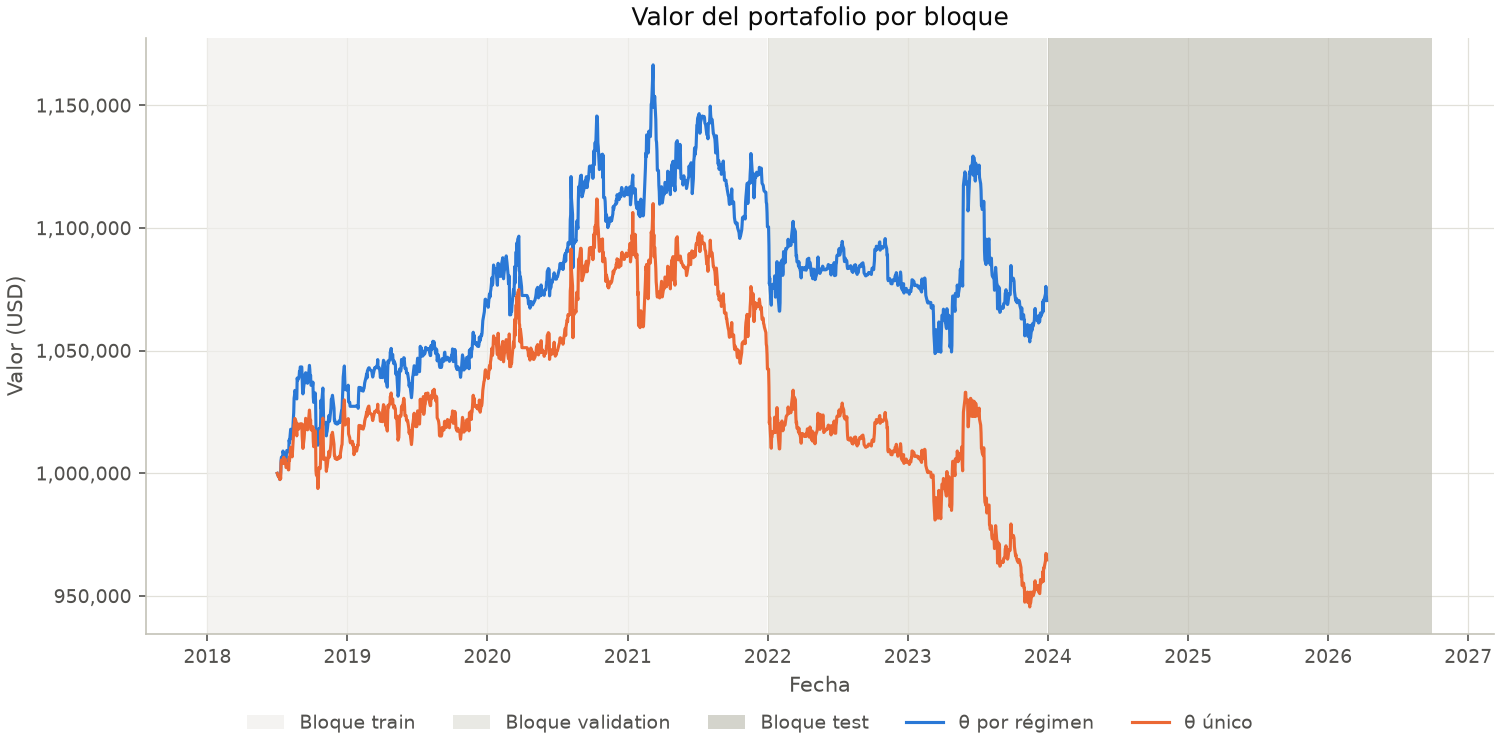

In [23]:
display(r["regimen_desempeno"]["theta_comparison"][columnas])
display(Image(filename=FIGURES / "regimen_theta_por_regimen_vs_unico.png"))

n_days  ann_return  sharpe  max_drawdown  n_trades  win_rate
variante    bloque     regimen                                                                 
por régimen train      tendencia 373.0000      0.0864  1.4440       -0.0381  106.0000    0.4057
                       reversion 272.0000     -0.0295 -0.7566       -0.0576   61.0000    0.3443
                       crisis    237.0000      0.0057 -0.0922       -0.0316   50.0000    0.6000
            validation tendencia 152.0000     -0.0076 -0.6700       -0.0528   26.0000    0.0769
                       reversion  93.0000     -0.0830 -2.6201       -0.0403   20.0000    0.3000
                       crisis    256.0000      0.0088 -0.4579       -0.0269   82.0000    0.4878
θ único     train      tendencia 373.0000      0.0455  0.6530       -0.0424  100.0000    0.3800
                       reversion 272.0000     -0.0300 -0.7631       -0.0548   59.0000    0.4068
                       crisis    237.0000      0.0092 -0.0195       -0.0297   47.0000    0.4255
            validation tendencia 152.0000     -0.0660 -1.6137       -0.0666   36.0000    0.1667
                       reversion  93.0000     -0.0844 -2.7886       -0.0418   21.0000    0.3810
                       crisis    256.0000     -0.0038 -0.9057       -0.0293   62.0000    0.4355

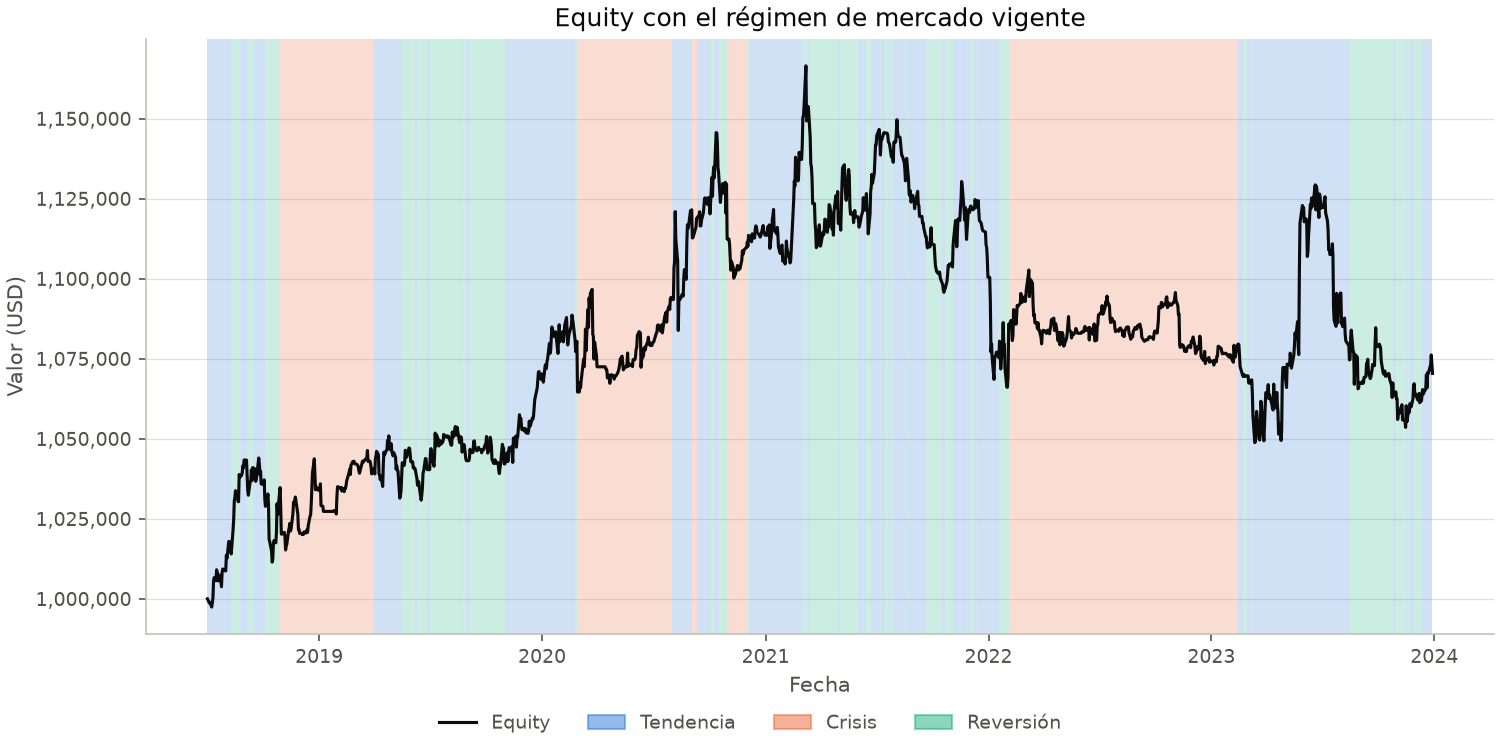

In [24]:
por_regimen = r["regimen_desempeno"]["by_regime"]
display(por_regimen.loc["rolling"][["n_days", "ann_return", "sharpe", "max_drawdown", "n_trades", "win_rate"]])
display(Image(filename=FIGURES / "regimen_equity_oos.png"))

## Backtests finales (walk-forward rolling por régimen)

### Métricas por bloque contra pesos iguales, buy & hold y cada activo

In [25]:
final = r["final_backtests"]
print("Bloques medidos:", {k: (str(a.date()), str(b.date())) for k, (a, b) in final["blocks"].items()})
display(final["metrics_by_block"][columnas].unstack("bloque").round(3))

Bloques medidos: {'train': ('2018-07-01', '2021-12-31'), 'validation': ('2022-01-01', '2023-12-31')}


ann_return            ann_vol             sharpe             calmar            max_drawdown            n_trades            win_rate           
bloque             train validation   train validation   train validation   train validation        train validation    train validation    train validation
estrategia                                                                                                                                                  
Risk Parity       0.0400    -0.0040  0.0510     0.0580  0.5940    -0.6450  0.8190    -0.0630      -0.0480    -0.0620      280        141   0.4790     0.4610
Pesos iguales     0.0510    -0.0040  0.0650     0.0740  0.6460    -0.4960  0.8910    -0.0560      -0.0570    -0.0770      280        141   0.4790     0.4610
AAPL              0.2770     0.1090  0.2350     0.2000  1.1140     0.4420  0.7860     0.6600      -0.3520    -0.1650       35         16   0.5430     0.5000
MSFT              0.0280    -0.1700  0.2040     0.2470  0.1920    -0.7730  0.0690    -0.3790      -0.4120    -0.4490       34         22   0.4710     0.3180
META              0.0280    -0.0730  0.2690     0.2950  0.2000    -0.2290  0.1030    -0.2040      -0.2750    -0.3570       33         22   0.4550     0.5000
AMD              -0.0120     0.1040  0.4450     0.3690  0.1710     0.3540 -0.0220     0.3420      -0.5580    -0.3030       38         17   0.5000     0.4710
XOM               0.0410    -0.1540  0.1920     0.2040  0.2540    -0.8870  0.1810    -0.4470      -0.2280    -0.3440       35         17   0.3430     0.4120
SMH              -0.0050     0.0740  0.2560     0.2410  0.0690     0.2680 -0.0150     0.4670      -0.3570    -0.1570       40         13   0.5250     0.5380
GLD              -0.0000     0.0220  0.0960     0.0950 -0.0590    -0.0910 -0.0020     0.2930      -0.1330    -0.0760       35         16   0.4290     0.5620
COPX              0.1950    -0.1540  0.2210     0.2090  0.8680    -0.8640  0.7410    -0.3710      -0.2620    -0.4140       35         21   0.5140     0.3810
Buy & hold        0.4000     0.0780  0.2880     0.2290  1.2790     0.2890  1.3190     0.3100      -0.3030    -0.2510        0          0      NaN        NaN

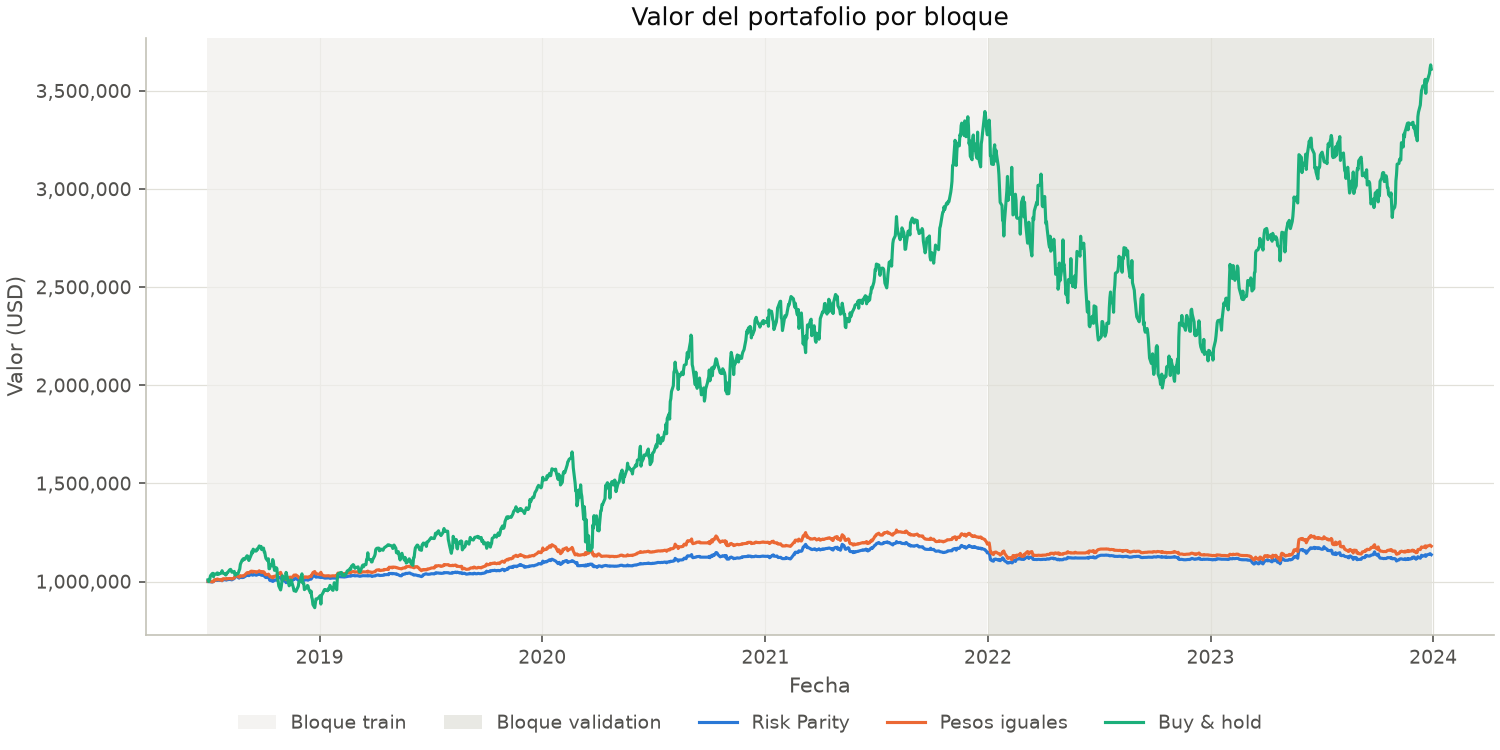

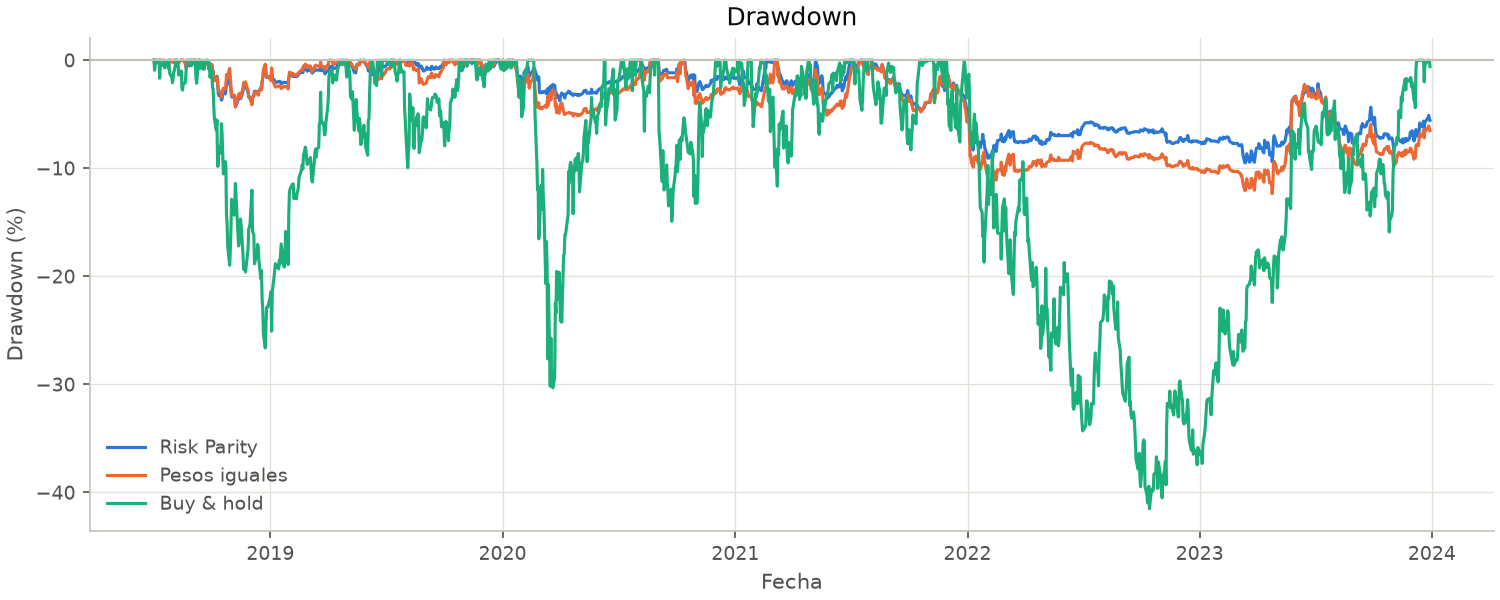

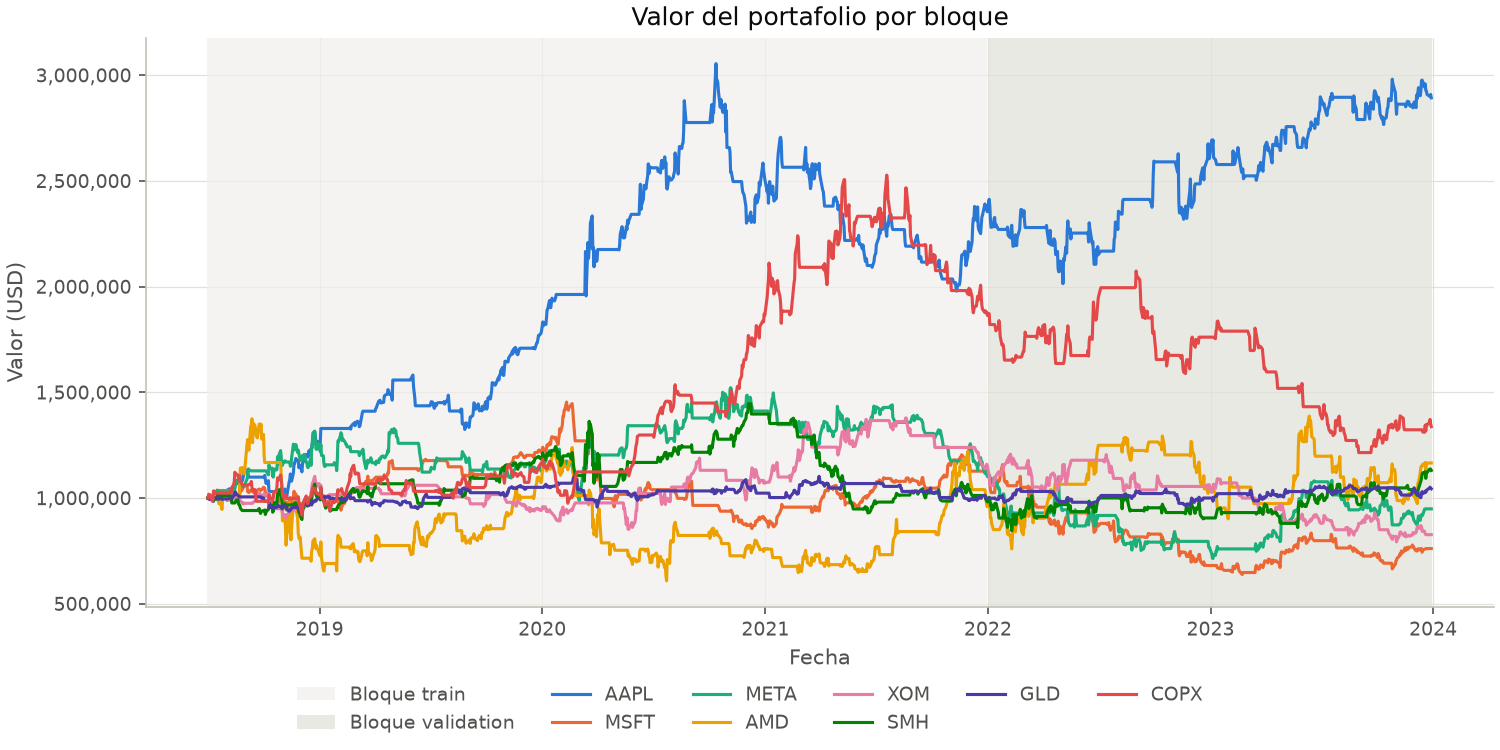

In [26]:
for name in ("final_equity", "final_drawdown", "final_equity_activos"):
    display(Image(filename=FIGURES / f"{name}.png"))

### Retornos mensuales, trimestrales y anuales de Risk Parity

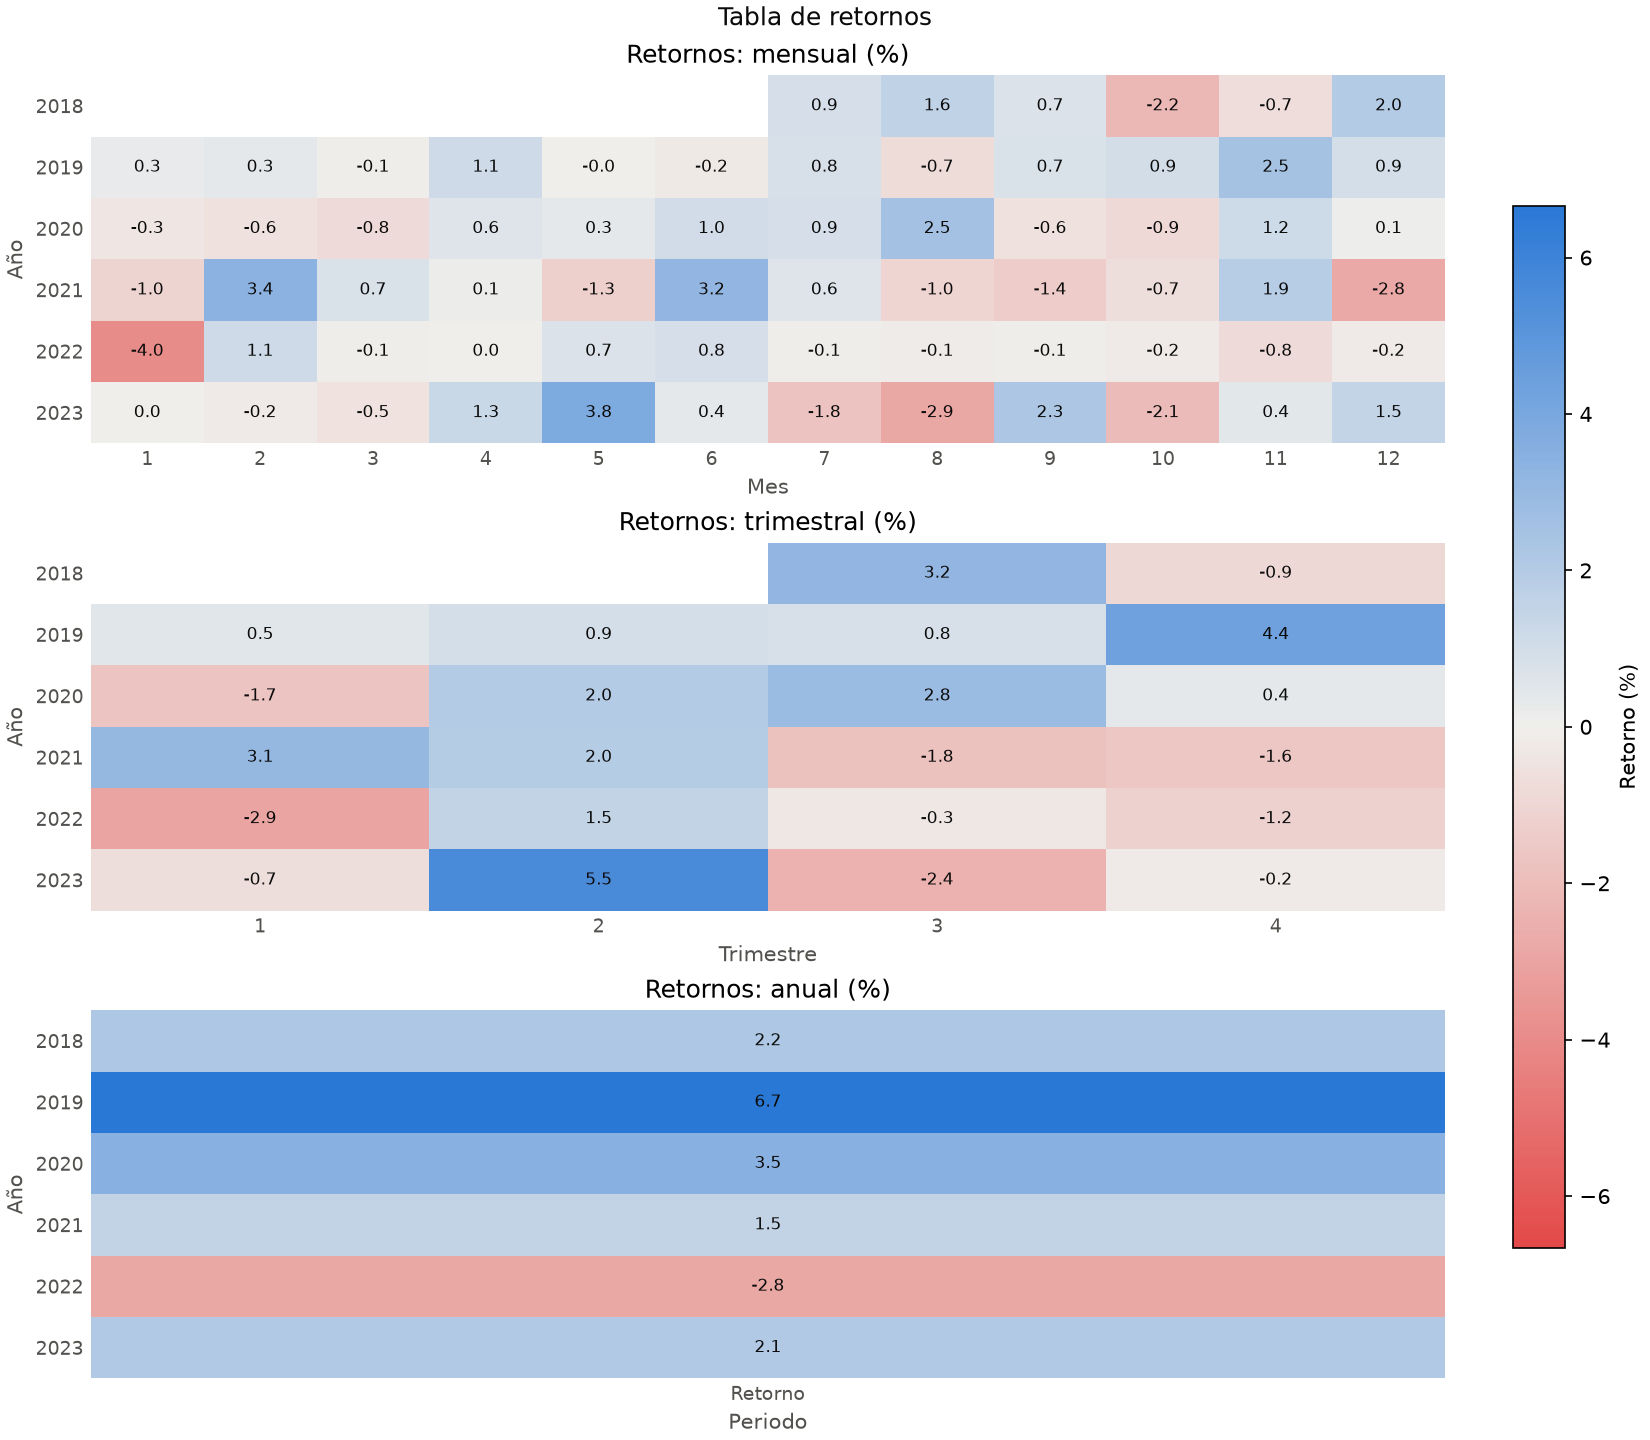

In [27]:
display(Image(filename=FIGURES / "final_retornos_risk_parity.png"))

### Exposición, break-even y señales

In [28]:
for name, metrics in final["exposure"].items():
    print(name, f"· tiempo en mercado {metrics['time_in_market_portfolio']:.0%}",
          f"· {metrics['trades_per_month']:.1f} operaciones/mes")
    display(metrics["exit_reasons"].to_frame().T)
display(final["breakeven"])

Risk Parity · tiempo en mercado 76% · 5.0 operaciones/mes


exit_reason,signal,stop,target,max_holding
count,24,138,59,200


Pesos iguales · tiempo en mercado 76% · 5.0 operaciones/mes


exit_reason,signal,stop,target,max_holding
count,24,138,59,200


,theoretical_win_rate,empirical_breakeven_win_rate,observed_win_rate,payoff_ratio,cost_in_r
train,0.2656,0.4399,0.4786,1.2733,0.0431
validation,0.2656,0.4330,0.4610,1.3094,0.0431


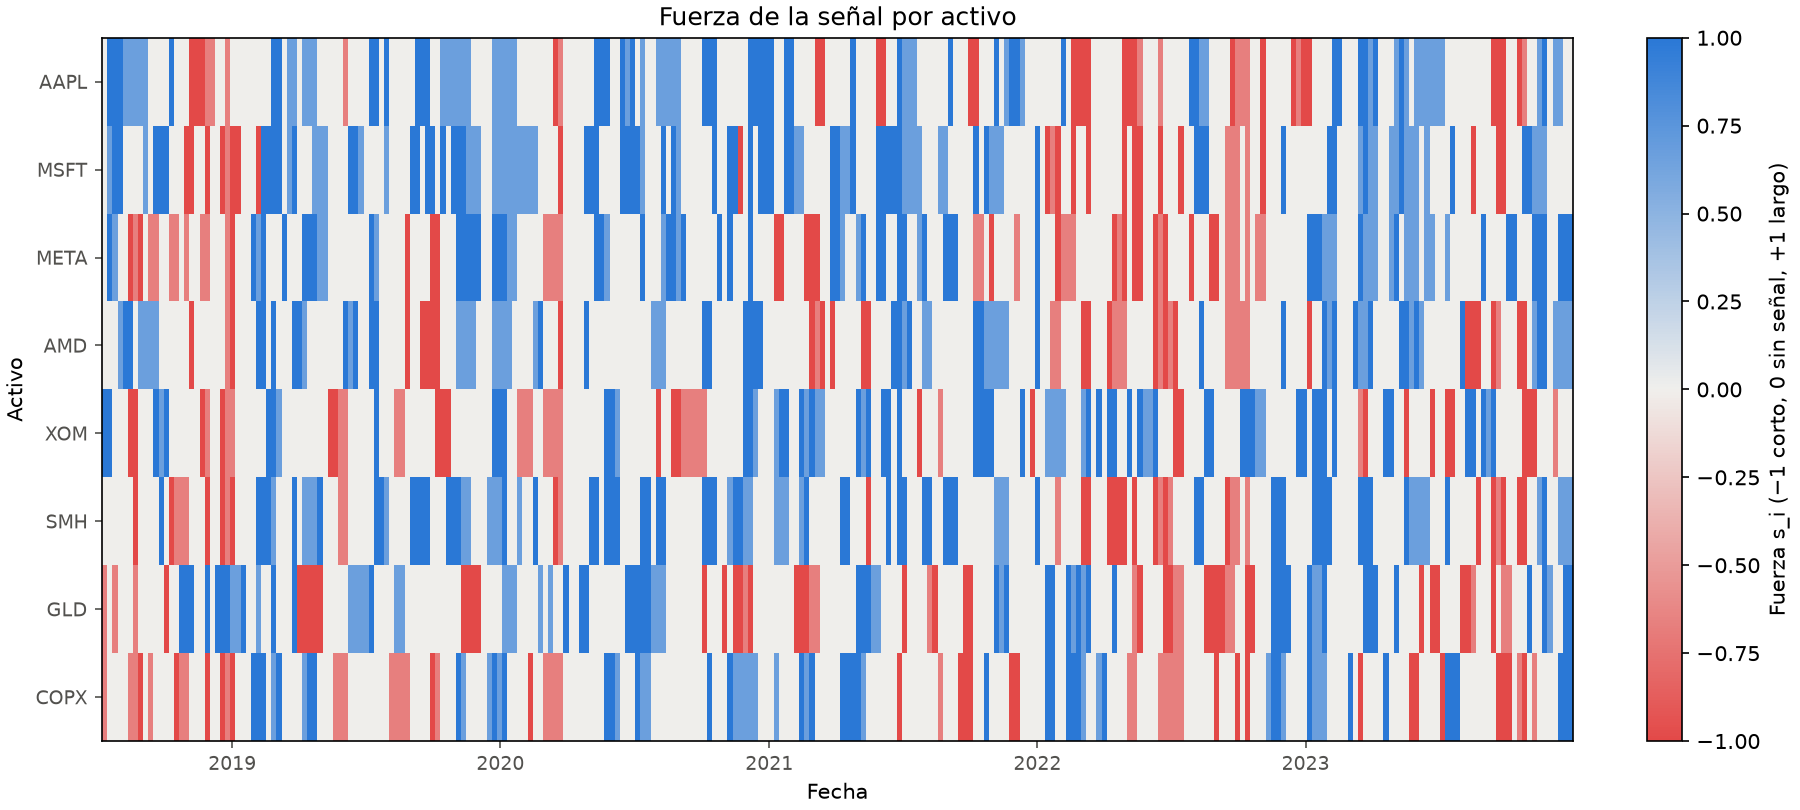

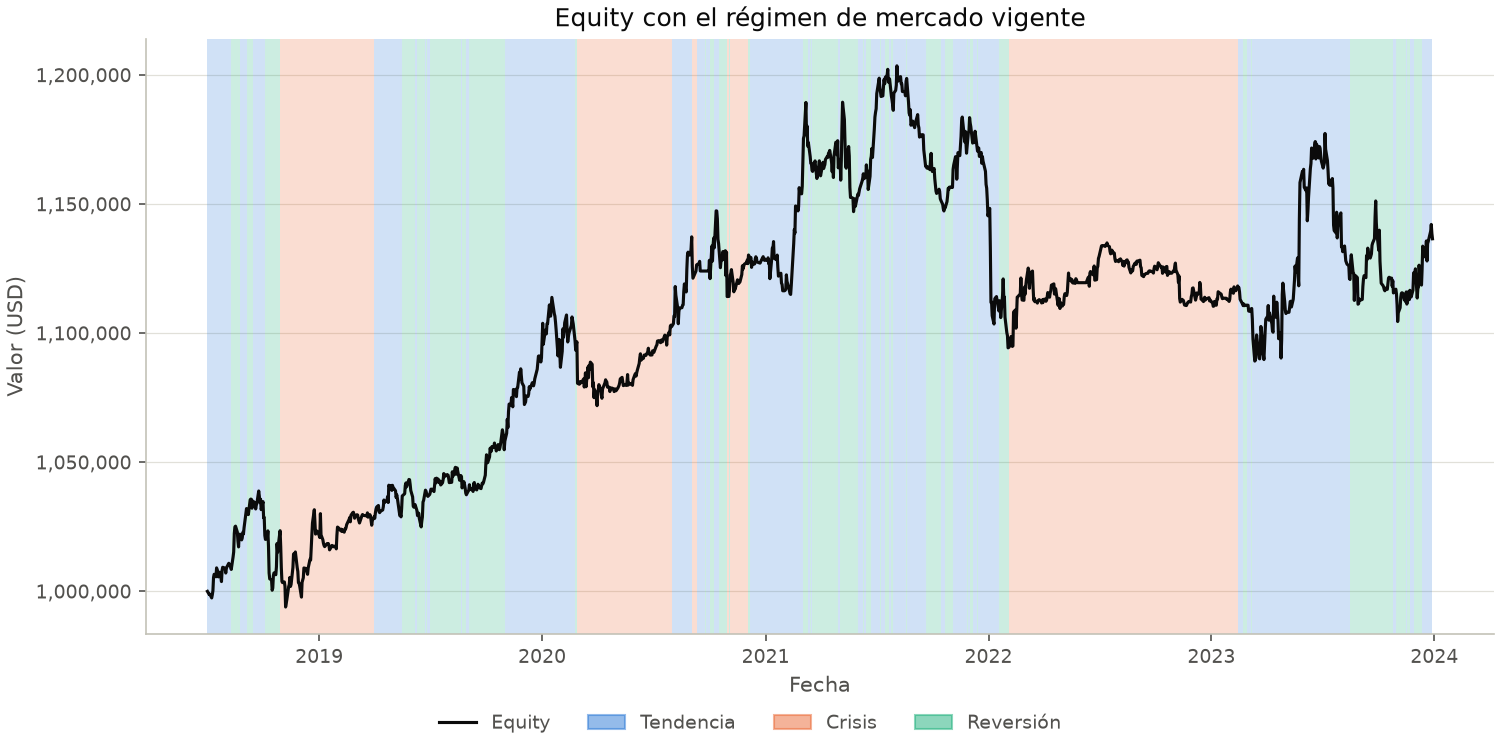

In [29]:
display(Image(filename=FIGURES / "final_mapa_senales.png"))
display(Image(filename=FIGURES / "final_equity_regimen.png"))

## Impacto de mercado ex post (P1, tarea 10)

In [30]:
impacto = r["impacto_mercado"]["summary"]
display(pd.Series({k: v for k, v in impacto.items() if k != "by_ticker_bps"}))
display(impacto["by_ticker_bps"].rename("bps promedio por llenado"))

block                (2022-01-01 00:00:00, 2023-12-31 00:00:00)
n_trades                                                    141
mean_bps                                                 2.3218
median_bps                                               0.8581
p95_bps                                                 11.8572
max_participation                                        0.0083
impact_cost                                          4,661.0421
impact_pct_equity                                        0.0041
block_return                                            -0.0103
impact_pct_return                                       -0.3955
dtype: object

ticker
AAPL    0.3837
AMD     0.7441
COPX   10.7698
GLD     1.0312
META    0.7287
MSFT    0.4885
SMH     1.3772
XOM     1.3291
Name: bps promedio por llenado, dtype: float64

## Auditoría de sesgos (P1, tarea 5)

In [31]:
display(Markdown((RESULTS / "auditoria_sesgos.md").read_text(encoding="utf-8")))

# Auditoría de sesgos

| Sesgo | Evidencia |
|---|---|
| Look-ahead | La señal de t se ejecuta al Open de t+1 y ese desplazamiento solo existe en `run_backtest`. Pruebas de truncamiento en verde para indicadores y señales (`test_signals.py`), régimen (`test_regimes.py`), pesos (`test_portfolio.py`) y el pipeline completo (`test_pipeline.py`); golden test 9 (t → t+1). El régimen operado es la etiqueta filtrada (forward); Viterbi solo aparece en una figura. |
| Survivorship | Los 8 activos se eligieron en 2026 entre empresas y ETFs que sobrevivieron hasta hoy, así que el resultado está sesgado al alza. Datos completos y traslapados: 2,449 días comunes de 2017-01-03 a 2026-09-30, 0 fechas descartadas y 0 incidencias de calidad. |
| Overfitting / data snooping | Optuna TPE con 150 pruebas por estudio y ventana del walk-forward (88,200 configuraciones evaluadas en total), más 200 random y 200 TPE de diagnóstico. Se elige el medoide del mejor 10% (meseta), no el máximo. m(régimen) no entra al espacio de búsqueda. Eficiencia del walk-forward: rolling por régimen = 0.14, rolling θ único = -0.07, anchored por régimen = 0.09, anchored θ único = 0.15. Test se corre una sola vez con θ congelados. |
| Ejecución optimista | Ejecución al Open de t+1 con slippage de 2 bps en contra en todo llenado, incluidos SL y TP; comisión de 0.125% por lado y borrow en cortos. Empate intrabarra: primero el stop. Gap más allá del TP llena en el TP, sin mejora. Impacto de mercado no modelado; estimado ex post sobre 141 operaciones de validation: 2.3 bps promedio por llenado (p95 11.9 bps), 0.41% del equity inicial del bloque. |
| Selección de muestra / periodo | Rango 2017-01-02 → 2026-09-30 y partición train / validation / test fijados en el SPEC antes de ver resultados; 2017 solo calienta indicadores. El walk-forward corre continuo sobre los tres bloques. Validation se usa una vez para decisiones discretas. |
